In [1]:
"""
Stage 0 — Data Ingestion: Transcript Parsing & Price Loading
=============================================================
This script:
  1. Unzips and organizes the 131 earnings-call transcripts
  2. Parses each transcript into structured data (header, prepared remarks, Q&A pairs)
  3. Fetches stock prices for all 14 tickers + SPY via yfinance
  4. Computes forward excess returns at multiple horizons
  5. Saves everything to disk so downstream notebooks never repeat this work

Usage:
  - Adjust ECT_ZIP path below to wherever your ECT.zip lives
  - Run once. All outputs are cached to the 'cache/' directory.
"""

# ============================================================
# 0. IMPORTS & SETUP
# ============================================================

import os, re, json, zipfile, time
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import List, Dict, Optional, Tuple
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from tqdm import tqdm

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

# ============================================================
# 1. PATHS — Edit to match your setup
# ============================================================

ROOT = Path.cwd()
# Look for transcripts under ./ECT by default; override with the ECT_DIR env var.
# See README for setup instructions.
TRANSCRIPTS = Path(os.environ.get('ECT_DIR', ROOT / 'ECT'))

if not TRANSCRIPTS.exists():
    raise FileNotFoundError(
        f"Transcripts directory not found at {TRANSCRIPTS}. "
        f"Either unzip ECT.zip into ./ECT or set the ECT_DIR environment variable."
    )
CACHE       = ROOT / 'cache'
EXTRACTIONS = CACHE / 'extractions'
PRICES      = CACHE / 'prices'
FIGURES     = ROOT / 'figures'

for d in (CACHE, EXTRACTIONS, PRICES, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

txts = sorted(TRANSCRIPTS.glob('*.txt'))
print(f'{len(txts)} transcripts found')


131 transcripts found


In [2]:
# ============================================================
# 3. TRANSCRIPT PARSER
# ============================================================
#
# Splits each transcript into:
#   - header info (ticker, quarter, call_date, company)
#   - prepared_remarks: list of {role, text} from the Presentation section
#   - qa_pairs: list of {q_role, question, a_role, answer} from the Q&A section
#
# Handles edge cases:
#   - Orphan Answer blocks (Answer without a preceding Question)
#   - The odd FAST_2026_01_20.txt filename
#   - BOM characters at the start of files
#   - PLTR transcripts have no "Question and Answer Operator Message" header
#     and only one "Presenter Speech" block covering all executives (29K+ chars)
#     — parser detects Q&A onset from the first Answer/Question section header

SECTION_HEADERS = {
    'Presentation Operator Message',
    'Presenter Speech',
    'Question and Answer Operator Message',
    'Question',
    'Answer',
}

HEADER_RE = re.compile(
    r'^(?P<company>.+?),\s*'
    r'(?:Q(?P<q>\d)\s*(?P<y>\d{4})|(?P<alt_y>\d{4}))\s*'
    r'Earnings Call.*?'
    r'(?P<date>[A-Z][a-z]+ \d{1,2},\s*\d{4})'
)


@dataclass
class Transcript:
    ticker: str
    quarter: str          # e.g. 'Q4-2025'
    call_date: str        # 'YYYY-MM-DD'
    company: str
    prepared: List[Dict]  # [{'role': ..., 'text': ...}]
    qa: List[Dict]        # [{'q_role':..., 'question':..., 'a_role':..., 'answer':...}]
    raw_path: str
    n_prepared: int = 0
    n_qa: int = 0


def _filename_meta(path: Path) -> Tuple[str, str]:
    """Extract ticker and quarter from filename.
    
    Handles standard format: AMD_Q4-2025.txt
    And oddball format:      FAST_2026_01_20.txt
    """
    stem = path.stem
    ticker = stem.split('_')[0]
    
    # Standard format: TICKER_QN-YYYY
    m = re.match(r'^[A-Z]+_Q(\d)-(\d{4})$', stem)
    if m:
        return ticker, f'Q{m.group(1)}-{m.group(2)}'
    
    # Oddball: we'll extract quarter from the header line instead
    return ticker, None


def _blocks(text: str):
    """Yield (section_header, role_line, body_text) tuples."""
    lines = text.splitlines()
    i, n = 0, len(lines)
    while i < n:
        line = lines[i].strip()
        if line in SECTION_HEADERS:
            section = line
            i += 1
            role = lines[i].strip() if i < n else ''
            i += 1
            buf = []
            while i < n and lines[i].strip() not in SECTION_HEADERS:
                buf.append(lines[i])
                i += 1
            yield section, role, '\n'.join(buf).strip()
        else:
            i += 1


def _infer_quarter_from_date(date_str: str) -> str:
    """Given a call date, infer which fiscal quarter it reports.
    
    Earnings calls typically happen 1-2 months after quarter end:
      Q4 calls: Jan-Feb    Q1 calls: Apr-May
      Q2 calls: Jul-Aug    Q3 calls: Oct-Nov
    """
    dt = datetime.strptime(date_str, '%Y-%m-%d')
    month = dt.month
    year = dt.year
    
    if month <= 2:
        return f'Q4-{year - 1}'
    elif month <= 5:
        return f'Q1-{year}'
    elif month <= 8:
        return f'Q2-{year}'
    elif month <= 11:
        return f'Q3-{year}'
    else:
        return f'Q4-{year}'


def parse_transcript(path: Path) -> Transcript:
    """Parse a single transcript file into structured data."""
    text = path.read_text(errors='ignore')
    
    # Strip BOM
    text = text.lstrip('\ufeff')
    
    # Parse header line
    first_line = text.splitlines()[0].strip()
    m = HEADER_RE.match(first_line)
    
    if m:
        company = m.group('company').strip()
        raw_date = m.group('date').replace('  ', ' ')
        call_date = datetime.strptime(raw_date, '%b %d, %Y').strftime('%Y-%m-%d')
        
        if m.group('q'):
            quarter_from_header = f"Q{m.group('q')}-{m.group('y')}"
        else:
            quarter_from_header = None
    else:
        company, call_date = '', None
        quarter_from_header = None
    
    # Parse sections
    prepared, qa = [], []
    current_q = None
    in_qa = False

    for section, role, body in _blocks(text):
        if section == 'Question and Answer Operator Message':
            in_qa = True
            continue
        
        # Some transcripts (e.g. PLTR) have no "Question and Answer Operator Message"
        # — they jump straight to Question/Answer blocks. Detect this and switch.
        if not in_qa and section in ('Question', 'Answer'):
            in_qa = True
        
        if not in_qa and section == 'Presenter Speech':
            prepared.append({'role': role, 'text': body})
        elif in_qa and section == 'Question':
            current_q = {'q_role': role, 'question': body, 'a_role': None, 'answer': None}
            qa.append(current_q)
        elif in_qa and section == 'Answer':
            if current_q is None or current_q['answer'] is not None:
                # Orphan answer — create a stub
                current_q = {'q_role': None, 'question': '', 'a_role': role, 'answer': body}
                qa.append(current_q)
            else:
                current_q['a_role'] = role
                current_q['answer'] = body

    # Determine ticker and quarter
    ticker, quarter_from_filename = _filename_meta(path)
    
    # Use filename quarter if available, else header, else infer from date
    quarter = quarter_from_filename or quarter_from_header
    if quarter is None and call_date:
        quarter = _infer_quarter_from_date(call_date)
    
    t = Transcript(
        ticker=ticker,
        quarter=quarter or 'UNKNOWN',
        call_date=call_date,
        company=company,
        prepared=prepared,
        qa=qa,
        raw_path=str(path),
        n_prepared=len(prepared),
        n_qa=len(qa),
    )
    return t


# ---- Parse all transcripts ----
print("\nParsing transcripts...")
transcripts = [parse_transcript(p) for p in tqdm(txts, desc='parsing')]
print(f'Parsed {len(transcripts)} transcripts')

# ---- Quick sanity check ----
print("\n--- Sanity Check ---")
for t in transcripts[:3]:
    print(f'  {t.ticker:5s} {t.quarter:8s}  date={t.call_date}  '
          f'prepared={t.n_prepared} blocks  qa={t.n_qa} pairs  '
          f'company="{t.company[:40]}"')

# Check for any parsing issues
issues = [t for t in transcripts if t.n_prepared == 0 or t.n_qa == 0 or t.call_date is None]
if issues:
    print(f"\n⚠️  {len(issues)} transcripts with potential issues:")
    for t in issues:
        print(f'  {t.ticker} {t.quarter} — prepared={t.n_prepared}, qa={t.n_qa}, date={t.call_date}')
else:
    print("✓ All transcripts parsed successfully")

# ---- Summary table ----
summary = pd.DataFrame([{
    'ticker': t.ticker,
    'quarter': t.quarter,
    'call_date': t.call_date,
    'company': t.company[:50],
    'n_prepared': t.n_prepared,
    'n_qa': t.n_qa,
    'file_size_kb': round(os.path.getsize(t.raw_path) / 1024, 1),
} for t in transcripts])

summary['call_date'] = pd.to_datetime(summary['call_date'])
summary = summary.sort_values(['ticker', 'call_date']).reset_index(drop=True)

print(f"\n--- Calls per ticker ---")
print(summary.groupby('ticker').size().to_string())
print(f"\n--- Date range ---")
print(f"Earliest call: {summary.call_date.min().strftime('%Y-%m-%d')}")
print(f"Latest call:   {summary.call_date.max().strftime('%Y-%m-%d')}")

# Save parsed metadata to cache
summary.to_csv(CACHE / 'transcript_metadata.csv', index=False)
print(f"\n✓ Metadata saved to {CACHE / 'transcript_metadata.csv'}")


Parsing transcripts...


parsing: 100%|██████████| 131/131 [00:00<00:00, 928.14it/s]

Parsed 131 transcripts

--- Sanity Check ---
  AMD   Q1-2024   date=2024-04-30  prepared=1 blocks  qa=25 pairs  company="Advanced Micro Devices, Inc."
  AMD   Q1-2025   date=2025-05-06  prepared=1 blocks  qa=20 pairs  company="Advanced Micro Devices, Inc."
  AMD   Q2-2024   date=2024-07-30  prepared=1 blocks  qa=16 pairs  company="Advanced Micro Devices, Inc."
✓ All transcripts parsed successfully

--- Calls per ticker ---
ticker
AMD      9
AVGO     9
BLK     10
C        9
FAST    10
FDX      9
GS      10
INTC     9
JNJ     10
JPM     10
NKE      9
NVDA     9
PLTR     9
WFC      9

--- Date range ---
Earliest call: 2024-01-12
Latest call:   2026-04-14

✓ Metadata saved to c:\Users\loren\Desktop\MTH9796\cache\transcript_metadata.csv



C:\Users\loren\AppData\Local\Temp\ipykernel_31764\2487088017.py:215: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  summary['call_date'] = pd.to_datetime(summary['call_date'])


In [3]:
# ============================================================
# 4. PRICE DATA VIA YFINANCE
# ============================================================

import yfinance as yf

HORIZONS_DAYS = [1, 5, 21, 63]   # ~1d, 1w, 1m, 3m

def fetch_prices(ticker: str, start='2023-09-01', end=None) -> pd.DataFrame:
    """Download and cache daily close prices for a ticker."""
    cache_path = PRICES / f'{ticker}.parquet'
    
    # Use cached version if less than 24h old
    if cache_path.exists() and (time.time() - cache_path.stat().st_mtime) < 24 * 3600:
        return pd.read_parquet(cache_path)
    
    end = end or datetime.now().strftime('%Y-%m-%d')
    df = yf.Ticker(ticker).history(start=start, end=end, auto_adjust=True)
    df = df[['Close']].reset_index()
    df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None).dt.normalize()
    df.to_parquet(cache_path)
    time.sleep(0.3)   # rate-limit courtesy
    return df


# Fetch all tickers + SPY benchmark
all_tickers = sorted({t.ticker for t in transcripts})
print(f"\nFetching prices for {len(all_tickers)} tickers + SPY...")

prices = {}
for t in tqdm(all_tickers + ['SPY'], desc='prices'):
    try:
        prices[t] = fetch_prices(t)
    except Exception as e:
        print(f"  ⚠️  Failed to fetch {t}: {e}")

print(f"✓ Prices fetched for {len(prices)} tickers")


Fetching prices for 14 tickers + SPY...


prices: 100%|██████████| 15/15 [00:00<00:00, 82.57it/s]

✓ Prices fetched for 15 tickers


In [4]:
# ============================================================
# 5. FORWARD RETURNS
# ============================================================

def forward_return(ticker: str, call_date: str, horizon: int, 
                   use_excess: bool = True) -> Optional[float]:
    """Compute forward return starting T+1 after the call date.
    
    Uses T+1 to avoid look-ahead bias (calls happen after market close).
    If use_excess=True, subtracts the SPY return over the same window.
    """
    if ticker not in prices or 'SPY' not in prices:
        return None
    
    df = prices[ticker]
    spy = prices['SPY']
    d0 = pd.Timestamp(call_date)
    
    # Entry = first trading day strictly after call date
    entry_rows = df[df.Date > d0].head(1)
    if entry_rows.empty:
        return None
    
    entry_date = entry_rows.Date.iloc[0]
    entry_idx = df.index[df.Date == entry_date][0]
    
    # Exit = entry + horizon trading days
    if entry_idx + horizon >= len(df):
        return None
    
    exit_date = df.Date.iloc[entry_idx + horizon]
    
    # Stock return
    r = df.Close.iloc[entry_idx + horizon] / df.Close.iloc[entry_idx] - 1
    
    # Subtract benchmark return for excess return
    if use_excess:
        sp_entry = spy[spy.Date == entry_date]
        sp_exit = spy[spy.Date == exit_date]
        if sp_entry.empty or sp_exit.empty:
            return None
        r -= (sp_exit.Close.iloc[0] / sp_entry.Close.iloc[0] - 1)
    
    return float(r)


# Build the returns table
print("\nComputing forward returns...")
return_rows = []
for t in transcripts:
    if not t.call_date:
        continue
    row = {
        'ticker': t.ticker,
        'quarter': t.quarter,
        'call_date': t.call_date,
    }
    for h in HORIZONS_DAYS:
        row[f'fwd_excess_{h}d'] = forward_return(t.ticker, t.call_date, h)
        row[f'fwd_raw_{h}d'] = forward_return(t.ticker, t.call_date, h, use_excess=False)
    return_rows.append(row)

returns_df = pd.DataFrame(return_rows)
returns_df['call_date'] = pd.to_datetime(returns_df['call_date'])
returns_df = returns_df.sort_values(['ticker', 'call_date']).reset_index(drop=True)

print(f"\n--- Returns table: {len(returns_df)} rows ---")
print(returns_df.head(10).to_string())

# Check for NaN rates
nan_rates = returns_df.filter(like='fwd_').isna().mean().round(3)
print(f"\nNaN rates (expect some for most recent calls):")
print(nan_rates.to_string())

# Save to cache
returns_df.to_csv(CACHE / 'returns.csv', index=False)
print(f"\n✓ Returns saved to {CACHE / 'returns.csv'}")

# ============================================================
# 6. SAVE PARSED TRANSCRIPTS (for Task 1 extraction)
# ============================================================

# Save full parsed transcripts as JSON for the extraction step
import pickle

transcript_data = [asdict(t) for t in transcripts]
with open(CACHE / 'parsed_transcripts.pkl', 'wb') as f:
    pickle.dump(transcripts, f)

# Also save a lightweight JSON version (without full text) for inspection
transcript_meta = [{
    'ticker': t.ticker,
    'quarter': t.quarter,
    'call_date': t.call_date,
    'company': t.company,
    'n_prepared': t.n_prepared,
    'n_qa': t.n_qa,
    'raw_path': t.raw_path,
    'prepared_chars': sum(len(b['text']) for b in t.prepared),
    'qa_chars': sum(len(qa.get('question','') or '') + len(qa.get('answer','') or '') for qa in t.qa),
} for t in transcripts]

with open(CACHE / 'transcript_meta.json', 'w') as f:
    json.dump(transcript_meta, f, indent=2, default=str)

print(f"\n✓ Parsed transcripts saved to {CACHE / 'parsed_transcripts.pkl'}")
print(f"✓ Transcript metadata saved to {CACHE / 'transcript_meta.json'}")


Computing forward returns...

--- Returns table: 131 rows ---
  ticker  quarter  call_date  fwd_excess_1d  fwd_raw_1d  fwd_excess_5d  fwd_raw_5d  fwd_excess_21d  fwd_raw_21d  fwd_excess_63d  fwd_raw_63d
0    AMD  Q4-2023 2024-01-30       0.003550    0.016638      -0.012138    0.019381        0.146355     0.208420       -0.179061    -0.139662
1    AMD  Q1-2024 2024-04-30       0.003747    0.013100       0.031153    0.064809        0.102857     0.156859       -0.170067    -0.081306
2    AMD  Q2-2024 2024-07-30      -0.068480   -0.082641      -0.051058   -0.109427       -0.006698     0.006991        0.091230     0.150678
3    AMD  Q3-2024 2024-10-29      -0.010881   -0.030485      -0.042570   -0.023553       -0.115712    -0.076851       -0.265112    -0.231023
4    AMD  Q4-2024 2025-02-04      -0.019992   -0.016516      -0.001166   -0.002589       -0.057618    -0.104455       -0.035520    -0.104009
5    AMD  Q1-2025 2025-05-06       0.006384    0.013352       0.125860    0.172977        0

C:\Users\loren\AppData\Local\Temp\ipykernel_31764\1897652097.py:64: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  returns_df['call_date'] = pd.to_datetime(returns_df['call_date'])


In [5]:

# ============================================================
# 7. FINAL SUMMARY
# ============================================================

print("\n" + "="*60)
print("  STAGE 0 COMPLETE — Data Ingestion Summary")
print("="*60)
print(f"  Transcripts parsed:  {len(transcripts)}")
print(f"  Tickers:             {len(all_tickers)} — {', '.join(all_tickers)}")
print(f"  Date range:          {returns_df.call_date.min().strftime('%Y-%m-%d')} to "
      f"{returns_df.call_date.max().strftime('%Y-%m-%d')}")
print(f"  Returns computed:    {len(returns_df)} rows × {len(HORIZONS_DAYS)} horizons")
print(f"  Horizons:            {HORIZONS_DAYS} trading days")
print(f"")
print(f"  Cached files:")
print(f"    {CACHE / 'parsed_transcripts.pkl'}")
print(f"    {CACHE / 'returns.csv'}")
print(f"    {CACHE / 'transcript_metadata.csv'}")
print(f"    {PRICES}/*.parquet")
print("="*60)
print("\n→ Next step: Run 02_llm_extraction.py to extract sentiment,")
print("  wins, risks, and guidance from each transcript using Claude API.")


  STAGE 0 COMPLETE — Data Ingestion Summary
  Transcripts parsed:  131
  Tickers:             14 — AMD, AVGO, BLK, C, FAST, FDX, GS, INTC, JNJ, JPM, NKE, NVDA, PLTR, WFC
  Date range:          2024-01-12 to 2026-04-14
  Returns computed:    131 rows × 4 horizons
  Horizons:            [1, 5, 21, 63] trading days

  Cached files:
    c:\Users\loren\Desktop\MTH9796\cache\parsed_transcripts.pkl
    c:\Users\loren\Desktop\MTH9796\cache\returns.csv
    c:\Users\loren\Desktop\MTH9796\cache\transcript_metadata.csv
    c:\Users\loren\Desktop\MTH9796\cache\prices/*.parquet

→ Next step: Run 02_llm_extraction.py to extract sentiment,
  wins, risks, and guidance from each transcript using Claude API.


# Some Checks

In [6]:
# Pick any transcript and inspect it
t = transcripts[17]  # AMD Q4-2023
print(f"Ticker: {t.ticker}")
print(f"Quarter: {t.quarter}")
print(f"Date: {t.call_date}")
print(f"Company: {t.company}")
print(f"Prepared remarks blocks: {t.n_prepared}")
print(f"Q&A pairs: {t.n_qa}")
print(f"\n--- First prepared remarks speaker ---")
print(f"Role: {t.prepared[0]['role']}")
print(t.prepared[0]['text'][:500])  # first 500 chars
print(f"\n--- First Q&A pair ---")
print(f"Analyst: {t.qa[0]['q_role']}")
print(f"Question: {t.qa[0]['question'][:300]}")
print(f"Executive: {t.qa[0]['a_role']}")
print(f"Answer: {t.qa[0]['answer'][:300]}")

Ticker: AVGO
Quarter: Q4-2025
Date: 2025-12-11
Company: Broadcom Inc.
Prepared remarks blocks: 1
Q&A pairs: 13

--- First prepared remarks speaker ---
Role: Executives - Director of Investor Relations
Thank you, Sheri, and good afternoon, everyone. Joining me on today's call are Hock Tan, President and CEO; Kirsten Spears, Chief Financial Officer; and Charlie Kawwas, President, Semiconductor Solutions Group.
Broadcom distributed a press release and financial tables after the market close, describing our financial performance for the fourth quarter and fiscal year 2025. If you did not receive a copy, you may obtain the information from the Investors section of Broadcom's website at broadcom.co

--- First Q&A pair ---
Analyst: Analysts - MD in Equity Research & Senior Semiconductor Analyst
Question: Just wanted to clarify, Hock, you said $73 billion over 18 months for AI, that's roughly $50-ish billion plus for fiscal '26 for AI. I just wanted to get -- make sure I got that right.
And th

In [7]:
# Compare against what you know — NVDA should have huge Q&A sections
for t in transcripts:
    if t.ticker == 'NVDA':
        print(f"{t.quarter}  date={t.call_date}  prepared={t.n_prepared}  qa={t.n_qa}  "
              f"prepared_chars={sum(len(b['text']) for b in t.prepared)}")

Q1-2025  date=2024-05-22  prepared=1  qa=12  prepared_chars=21038
Q1-2026  date=2025-05-28  prepared=1  qa=7  prepared_chars=24140
Q2-2025  date=2024-08-28  prepared=1  qa=10  prepared_chars=15496
Q2-2026  date=2025-08-27  prepared=1  qa=8  prepared_chars=18493
Q3-2025  date=2024-11-20  prepared=1  qa=11  prepared_chars=15707
Q3-2026  date=2025-11-19  prepared=1  qa=9  prepared_chars=20972
Q4-2024  date=2024-02-21  prepared=1  qa=11  prepared_chars=36009
Q4-2025  date=2025-02-26  prepared=1  qa=10  prepared_chars=16027
Q4-2026  date=2026-02-25  prepared=1  qa=13  prepared_chars=16691


In [8]:
import pandas as pd
df = pd.read_csv('cache/transcript_metadata.csv')
print(df.to_string())

    ticker  quarter   call_date                        company  n_prepared  n_qa  file_size_kb
0      AMD  Q4-2023  2024-01-30   Advanced Micro Devices, Inc.           1    20          53.4
1      AMD  Q1-2024  2024-04-30   Advanced Micro Devices, Inc.           1    25          52.1
2      AMD  Q2-2024  2024-07-30   Advanced Micro Devices, Inc.           1    16          47.5
3      AMD  Q3-2024  2024-10-29   Advanced Micro Devices, Inc.           1    22          55.3
4      AMD  Q4-2024  2025-02-04   Advanced Micro Devices, Inc.           1    16          50.9
5      AMD  Q1-2025  2025-05-06   Advanced Micro Devices, Inc.           1    20          54.6
6      AMD  Q2-2025  2025-08-05   Advanced Micro Devices, Inc.           1    18          53.8
7      AMD  Q3-2025  2025-11-04   Advanced Micro Devices, Inc.           1    21          49.2
8      AMD  Q4-2025  2026-02-03   Advanced Micro Devices, Inc.           1    19          49.1
9     AVGO  Q1-2024  2024-03-07                  B

# Step 1


In [9]:
"""
Task 1 — LLM Extraction: Sentiment, Wins, Risks, Guidance, Themes
===================================================================
This script:
  1. Loads the parsed transcripts from Stage 0
  2. Sends each transcript to the Claude API (Sonnet 4.6)
  3. Extracts structured JSON: sentiment, wins, risks, guidance, themes
  4. Caches every result to disk (never re-runs a transcript that's already done)
  5. Saves raw LLM output on parse failure for debugging

Setup:
  pip install anthropic
  
  Then either:
    - Set environment variable: ANTHROPIC_API_KEY=sk-ant-...
    - Or paste your key directly below (line ~30)

Cost estimate: ~$5-6 for all 131 transcripts using Sonnet 4.6
"""

import os, re, json, pickle, time
from pathlib import Path
from typing import Optional
from tqdm import tqdm

# ============================================================
# 1. CONFIG
# ============================================================

# --- API Key ---

API_KEY = os.environ.get('ANTHROPIC_API_KEY', '')

MODEL = 'claude-sonnet-4-6'
MAX_TOKENS = 4000

# --- Paths (must match Stage 0) ---
ROOT        = Path.cwd()
CACHE       = ROOT / 'cache'
EXTRACTIONS = CACHE / 'extractions'
EXTRACTIONS.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2. LOAD PARSED TRANSCRIPTS FROM STAGE 0
# ============================================================

with open(CACHE / 'parsed_transcripts.pkl', 'rb') as f:
    transcripts = pickle.load(f)

print(f'Loaded {len(transcripts)} parsed transcripts from Stage 0')

Loaded 131 parsed transcripts from Stage 0


In [10]:
# ============================================================
# 3. THE EXTRACTION PROMPT
# ============================================================

SYSTEM_PROMPT = """You are a senior equity research analyst. You will be given an earnings-call transcript.
Analyze it carefully and extract the structured data described below.
CRITICAL INSTRUCTIONS:
1. SCORE ONLY FROM THE LANGUAGE IN THE TRANSCRIPT. You must ignore any knowledge you have about what happened to the stock or the company after this call. Pretend you are reading this transcript live on the call date. Do not let hindsight influence sentiment, confidence, or any other score.
2. SENTIMENT MEASURES FORWARD-LOOKING TONE, NOT BACKWARD-LOOKING RESULTS. A company that posted great numbers but guided cautiously should score lower than one with okay numbers but aggressive forward guidance and confident language. What matters is: how does management feel about the future? Is the tone improving or defensive?

SCHEMA:
{
  "prepared_sentiment": <float in [-1.0, 1.0], forward-looking tone of the prepared remarks only — see SENTIMENT RUBRIC below>,
  "qa_sentiment": <float in [-1.0, 1.0], tone of the Q&A section only — see SENTIMENT RUBRIC below>,
  "management_confidence": <float in [0.0, 1.0] — see CONFIDENCE RUBRIC below>,
  "qa_defensiveness": <float in [0.0, 1.0], how defensive or evasive were executives in Q&A? Score this INDEPENDENTLY of overall sentiment — a confident CEO on a great quarter can still dodge a specific question, and a struggling CEO can still answer everything directly. 0 = direct, transparent, welcomed tough questions. 0.5 = somewhat guarded, pivoted away from some questions. 1.0 = clearly evasive, dodged questions, gave non-answers, became defensive when pressed>,
  "wins": [
    {"text": "<concrete positive event with numbers>", "category": "<revenue|margins|product|customer|growth|buybacks|cost_savings|other>"}
  ],
  "risks": [
    {"text": "<concrete negative event or concern>", "category": "<demand|margins|regulatory|competition|macro|supply_chain|customer_concentration|execution|other>"}
  ],
  "guidance": <"raised" | "reaffirmed" | "lowered" | "mixed" | "none">,
  "guidance_items": [
    {"line_item": "<revenue|eps|margins|segment|capex|other>", "direction": "<raised|reaffirmed|lowered>", "detail": "<brief specifics>"}
  ],
  "themes": [<select ONLY from the CLOSED THEME LIST below, up to 8 tags>],
  "analyst_concerns_not_in_prepared": [<up to 3 strings — topics that analysts raised in Q&A that management did NOT proactively mention in prepared remarks. These are "reactive" topics. Empty [] if all Q&A topics were covered.>]
}

NOTE: Do NOT return overall_sentiment or sentiment_bucket — I will compute those downstream from prepared_sentiment and qa_sentiment. Only return the fields listed above.

SENTIMENT RUBRIC (use this to calibrate — spread your scores across the full range):
  -1.0 to -0.7  VERY BEARISH: management sounds defeated, multiple guidance cuts, language like "significant headwinds", "difficult decisions", restructuring/layoffs announced, analysts openly skeptical
  -0.7 to -0.3  BEARISH: cautious tone, guidance lowered or at risk, defensive language, more risks than wins, hedging on outlook
  -0.3 to  0.0  SLIGHTLY BEARISH: mixed results leaning negative, guidance merely reaffirmed with caveats, tepid confidence
   0.0 to  0.3  SLIGHTLY BULLISH: decent results, guidance reaffirmed with modest optimism, stable but not exciting
   0.3 to  0.7  BULLISH: strong results, guidance raised or strong reaffirmation, confident forward-looking language, analysts largely supportive
   0.7 to  1.0  VERY BULLISH: blowout quarter, aggressive guidance raise, management ebullient, language like "unprecedented demand", "inflection point", multiple expansion themes, analysts congratulatory

CONFIDENCE RUBRIC:
  0.0-0.2: heavy hedging — "we hope", "we'll try", "it's hard to say", lots of qualifiers
  0.2-0.4: cautious — "we believe", "we expect" with caveats, measured language
  0.4-0.6: neutral/professional — standard corporate confidence, balanced
  0.6-0.8: confident — "we are confident", "well positioned", "strong momentum", specific commitments
  0.8-1.0: very confident — "we are certain", "no question", bold targets, CEO personally guaranteeing outcomes

CLOSED THEME LIST (use ONLY these tags):
  ai, cloud, data_center, edge_computing, autonomous,
  china_exposure, tariffs, regulatory, geopolitical,
  margin_expansion, margin_pressure, pricing_power, cost_cutting,
  capex, buybacks, dividends, m_and_a, restructuring, layoffs,
  supply_chain, inventory, product_launch, customer_wins, customer_loss,
  macro_headwinds, consumer_weakness, enterprise_demand, 
  debt_reduction, currency_fx, guidance_beat, guidance_miss

NOTE on guidance_beat / guidance_miss: these mean relative to the COMPANY'S OWN prior guidance (which is in the transcript), NOT relative to Wall Street consensus estimates (which would require outside knowledge).

EXAMPLE 1 — Strong semiconductor quarter (bullish, sentiment ~0.7):
{
  "prepared_sentiment": 0.80,
  "qa_sentiment": 0.55,
  "management_confidence": 0.85,
  "qa_defensiveness": 0.15,
  "wins": [
    {"text": "Data center revenue reached $5.4B, up 39% YoY driven by AI GPU demand", "category": "revenue"},
    {"text": "Gross margins expanded 210 bps to 58.3%, ahead of guidance", "category": "margins"},
    {"text": "Launched next-gen accelerator with 3 major cloud customers already committed", "category": "product"}
  ],
  "risks": [
    {"text": "China export restrictions expected to reduce revenue by ~$800M annually", "category": "regulatory"},
    {"text": "Top 4 hyperscaler customers represent 52% of data center revenue", "category": "customer_concentration"}
  ],
  "guidance": "raised",
  "guidance_items": [
    {"line_item": "revenue", "direction": "raised", "detail": "Q2 revenue guided to $5.8B +/- $200M, above prior $5.5B guide"}
  ],
  "themes": ["ai", "data_center", "china_exposure", "buybacks", "margin_expansion", "customer_wins"],
  "analyst_concerns_not_in_prepared": ["customer concentration risk in hyperscalers"]
}

EXAMPLE 2 — Typical large-cap bank quarter (slightly bullish, mixed signals, sentiment ~0.15):
{
  "prepared_sentiment": 0.25,
  "qa_sentiment": 0.05,
  "management_confidence": 0.55,
  "qa_defensiveness": 0.35,
  "wins": [
    {"text": "Investment banking fees rose 18% YoY to $2.1B on improved deal pipeline", "category": "revenue"},
    {"text": "Net interest income stable at $14.3B despite rate curve flattening", "category": "revenue"},
    {"text": "CET1 ratio improved to 13.8%, supporting $3B buyback authorization", "category": "buybacks"}
  ],
  "risks": [
    {"text": "Provision for credit losses increased 22% to $1.9B on commercial real estate exposure", "category": "execution"},
    {"text": "Trading revenue declined 8% QoQ as volatility normalized", "category": "demand"},
    {"text": "CFO flagged 'uncertain macro outlook' affecting loan growth", "category": "macro"}
  ],
  "guidance": "reaffirmed",
  "guidance_items": [
    {"line_item": "revenue", "direction": "reaffirmed", "detail": "Full-year NII expected in $57-58B range, unchanged"},
    {"line_item": "eps", "direction": "reaffirmed", "detail": "No change to FY EPS outlook"}
  ],
  "themes": ["macro_headwinds", "buybacks", "regulatory", "enterprise_demand"],
  "analyst_concerns_not_in_prepared": ["commercial real estate concentration in office segment"]
}

EXAMPLE 3 — Struggling retailer quarter (bearish, sentiment ~-0.55):
{
  "prepared_sentiment": -0.40,
  "qa_sentiment": -0.70,
  "management_confidence": 0.30,
  "qa_defensiveness": 0.65,
  "wins": [
    {"text": "Digital sales grew 3% YoY, partially offsetting store traffic decline", "category": "growth"},
    {"text": "Inventory reduced 8% through targeted markdowns", "category": "cost_savings"}
  ],
  "risks": [
    {"text": "Same-store sales declined 6% on weakening consumer demand in North America", "category": "demand"},
    {"text": "Gross margins compressed 340 bps to 41.2% due to heavy promotional activity", "category": "margins"},
    {"text": "Full-year EPS guidance lowered from $3.40-$3.60 to $2.90-$3.10", "category": "execution"},
    {"text": "CFO acknowledged 'challenging macro environment likely to persist through H2'", "category": "macro"}
  ],
  "guidance": "lowered",
  "guidance_items": [
    {"line_item": "eps", "direction": "lowered", "detail": "FY EPS cut to $2.90-$3.10 from $3.40-$3.60"},
    {"line_item": "revenue", "direction": "lowered", "detail": "Now expects flat to slightly negative revenue growth vs prior low-single-digit growth"}
  ],
  "themes": ["consumer_weakness", "margin_pressure", "inventory", "guidance_miss", "cost_cutting"],
  "analyst_concerns_not_in_prepared": ["potential dividend cut if margins stay compressed", "market share loss to competitors"]
}

RULES:
- Ground EVERY field in the actual transcript text. Do not invent or hallucinate.
- IGNORE what you know about subsequent stock price moves or company events. Score as if reading live.
- "wins" and "risks" must be specific and concrete — include actual numbers whenever the transcript provides them.
- Provide 3-5 wins and 3-5 risks. Prioritize the most material items.
- For guidance, carefully parse what the CFO says about next quarter or full year outlook. Break it down by line item.
- For analyst_concerns_not_in_prepared: compare Q&A topics against the prepared remarks. If an analyst asks about something management never mentioned proactively, that is a reactive topic.
- Use the SENTIMENT RUBRIC to spread BOTH prepared_sentiment and qa_sentiment across the full range. Do NOT cluster everything between 0.2 and 0.6.- Themes must come from the CLOSED THEME LIST only. Pick the most relevant ones."""

USER_PROMPT_TEMPLATE = """Analyze this earnings call transcript for {ticker} {quarter} (call date: {call_date}).

<prepared_remarks>
{prepared}
</prepared_remarks>

<qa_section>
{qa}
</qa_section>"""


def build_prompt(t) -> str:
    """Build the user message from a parsed Transcript object."""
    # Prepared remarks
    prepared_parts = []
    for block in t.prepared:
        prepared_parts.append(f"[{block['role']}]\n{block['text']}")
    prepared_text = '\n\n'.join(prepared_parts)
    
    # Q&A pairs
    qa_parts = []
    for pair in t.qa:
        q_role = pair.get('q_role') or 'Unknown'
        question = pair.get('question') or ''
        a_role = pair.get('a_role') or 'Unknown'
        answer = pair.get('answer') or ''
        qa_parts.append(f"[Q — {q_role}]\n{question}\n\n[A — {a_role}]\n{answer}")
    qa_text = '\n\n'.join(qa_parts)
    
    # Truncate if extremely long (safety valve — Sonnet handles 200K tokens)
    MAX_CHARS = 180_000
    if len(prepared_text) + len(qa_text) > MAX_CHARS:
        # Keep more prepared remarks, truncate Q&A
        qa_text = qa_text[:MAX_CHARS - len(prepared_text)]
        qa_text += '\n\n[... Q&A truncated for length ...]'
    
    return USER_PROMPT_TEMPLATE.format(
        ticker=t.ticker,
        quarter=t.quarter,
        call_date=t.call_date,
        prepared=prepared_text,
        qa=qa_text,
    )

import anthropic 
client = anthropic.Anthropic(api_key=API_KEY)


EXTRACT_TOOL = {
    "name": "extract_earnings_call",
    "description": "Extract structured sentiment, events, and guidance from an earnings call transcript.",
    "input_schema": {
        "type": "object",
        "properties": {
            "prepared_sentiment":    {"type": "number"},
            "qa_sentiment":          {"type": "number"},
            "management_confidence": {"type": "number"},
            "qa_defensiveness":      {"type": "number"},
            "wins": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "text":     {"type": "string"},
                        "category": {"type": "string", "enum": ["revenue","margins","product","customer","growth","buybacks","cost_savings","other"]}
                    },
                    "required": ["text", "category"]
                },
                "minItems": 3, "maxItems": 5
            },
            "risks": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "text":     {"type": "string"},
                        "category": {"type": "string", "enum": ["demand","margins","regulatory","competition","macro","supply_chain","customer_concentration","execution","other"]}
                    },
                    "required": ["text", "category"]
                },
                "minItems": 3, "maxItems": 5
            },
            "guidance": {"type": "string", "enum": ["raised","reaffirmed","lowered","mixed","none"]},
            "guidance_items": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "line_item":  {"type": "string", "enum": ["revenue","eps","margins","segment","capex","other"]},
                        "direction":  {"type": "string", "enum": ["raised","reaffirmed","lowered"]},
                        "detail":     {"type": "string"}
                    },
                    "required": ["line_item", "direction", "detail"]
                }
            },
            "themes": {
                "type": "array",
                "items": {"type": "string", "enum": [
                    "ai","cloud","data_center","edge_computing","autonomous",
                    "china_exposure","tariffs","regulatory","geopolitical",
                    "margin_expansion","margin_pressure","pricing_power","cost_cutting",
                    "capex","buybacks","dividends","m_and_a","restructuring","layoffs",
                    "supply_chain","inventory","product_launch","customer_wins","customer_loss",
                    "macro_headwinds","consumer_weakness","enterprise_demand",
                    "debt_reduction","currency_fx","guidance_beat","guidance_miss"
                ]},
                "maxItems": 8
            },
            "analyst_concerns_not_in_prepared": {
                "type": "array",
                "items": {"type": "string"},
                "maxItems": 3
            }
        },
        "required": ["prepared_sentiment","qa_sentiment","management_confidence","qa_defensiveness",
                      "wins","risks","guidance","guidance_items","themes","analyst_concerns_not_in_prepared"]
    }
}



def extract_one(t) -> dict:
    """Call Claude API with tool use to extract sentiment/events from one transcript."""
    cache_path = EXTRACTIONS / f'{t.ticker}_{t.quarter}.json'
    
    # Return cached result if it exists
    if cache_path.exists():
        return json.loads(cache_path.read_text())
    
    user_msg = build_prompt(t)
    
    try:
        response = client.messages.create(
            model=MODEL,
            max_tokens=MAX_TOKENS,
            temperature=0,
            system=SYSTEM_PROMPT,
            messages=[{"role": "user", "content": user_msg}],
            tools=[EXTRACT_TOOL],
            tool_choice={"type": "tool", "name": "extract_earnings_call"},
        )
        
        # With tool_choice forced, response.content[0] is a tool_use block
        # .input is already a validated dict — no JSON parsing needed
        result = response.content[0].input
        
        # Add metadata and compute derived fields
        result['_ticker'] = t.ticker
        result['_quarter'] = t.quarter
        result['_call_date'] = t.call_date
        
        # Derive overall_sentiment and bucket
        prep = result.get('prepared_sentiment', 0) or 0
        qa = result.get('qa_sentiment', 0) or 0
        result['overall_sentiment'] = round(0.6 * prep + 0.4 * qa, 3)
        
        boundaries = [(-0.7, 'very_bearish'), (-0.3, 'bearish'), (0.0, 'slightly_bearish'),
                       (0.3, 'slightly_bullish'), (0.7, 'bullish'), (float('inf'), 'very_bullish')]
        for threshold, label in boundaries:
            if result['overall_sentiment'] <= threshold:
                result['sentiment_bucket'] = label
                break
        
        cache_path.write_text(json.dumps(result, indent=2))
        return result
        
    except Exception as e:
        return {'_ticker': t.ticker, '_quarter': t.quarter, '_error': str(e)}



In [11]:
# ============================================================
# 5. RUN EXTRACTION
# ============================================================

# --- First: test on 2 transcripts to verify prompt quality ---

print("\n" + "="*60)
print("  STEP 1: Test extraction on 2 transcripts")
print("="*60)

# Pick one semiconductor (AMD) and one bank (JPM) to test
test_tickers = ['AMD', 'JPM']
test_transcripts = [t for t in transcripts 
                    if t.ticker in test_tickers and 'Q4-2025' in t.quarter]

if not test_transcripts:
    # Fallback: just grab the first transcript for each
    seen = set()
    for t in transcripts:
        if t.ticker in test_tickers and t.ticker not in seen:
            test_transcripts.append(t)
            seen.add(t.ticker)

print(f"Testing on: {[(t.ticker, t.quarter) for t in test_transcripts]}")
print("This will make 2 API calls (~$0.10)...\n")

for t in test_transcripts:
    print(f"--- {t.ticker} {t.quarter} ---")
    result = extract_one(t)
    
    if '_error' in result or '_parse_error' in result:
        print(f"  FAILED — check {EXTRACTIONS}/{t.ticker}_{t.quarter}.raw.txt")
    else:
        print(f"  Sentiment:   {result.get('overall_sentiment')} ({result.get('sentiment_bucket')})")
        print(f"    prepared={result.get('prepared_sentiment')}, qa={result.get('qa_sentiment')} → derived overall")
        print(f"  Confidence:  {result.get('management_confidence')}")
        print(f"  Q&A defense: {result.get('qa_defensiveness')}")
        wins = result.get('wins', [])
        for w in wins[:3]:
            txt = w['text'] if isinstance(w, dict) else w
            cat = f" [{w['category']}]" if isinstance(w, dict) else ''
            print(f"    ✓ {txt}{cat}")
        risks = result.get('risks', [])
        for r in risks[:3]:
            txt = r['text'] if isinstance(r, dict) else r
            cat = f" [{r['category']}]" if isinstance(r, dict) else ''
            print(f"    ✗ {txt}{cat}")
        print(f"  Guidance:    {result.get('guidance')}")
        for gi in result.get('guidance_items', []):
            print(f"    → {gi.get('line_item')}: {gi.get('direction')} — {gi.get('detail', '')[:80]}")
        print(f"  Themes:      {result.get('themes')}")
        reactive = result.get('analyst_concerns_not_in_prepared', [])
        if reactive:
            print(f"  Reactive:    {reactive}")
    print()


# Interactive confirmation removed for headless / grader runs.
# Extractions are cached, so re-running this cell will simply skip already-done transcripts.
# input_continue = input("Does the output look good? Press Enter to continue with all 131, or Ctrl+C to stop and adjust the prompt: ")

# --- Now: run on ALL transcripts ---

print("\n" + "="*60)
print("  STEP 2: Extract all 131 transcripts")
print("="*60)
print("Already-cached transcripts will be skipped.\n")

results = []
errors = []

for t in tqdm(transcripts, desc='extracting'):
    result = extract_one(t)
    results.append(result)
    
    if '_error' in result or '_parse_error' in result:
        errors.append(f"{t.ticker} {t.quarter}")
    
    # Small delay to be polite to the API
    time.sleep(0.2)


  STEP 1: Test extraction on 2 transcripts
Testing on: [('AMD', 'Q4-2025'), ('JPM', 'Q4-2025')]
This will make 2 API calls (~$0.10)...

--- AMD Q4-2025 ---
  Sentiment:   0.752 (very_bullish)
    prepared=0.82, qa=0.65 → derived overall
  Confidence:  0.85
  Q&A defense: 0.2
    ✓ Q4 revenue grew 34% YoY to a record $10.3B, with net income up 42% to a record $2.5B and free cash flow nearly doubling YoY to a record $2.1B [revenue]
    ✓ Data Center segment revenue hit a record $5.4B in Q4, up 39% YoY and 24% sequentially, driven by EPYC and MI350 ramp; operating margin expanded to 33% from 30% a year ago [margins]
    ✓ Client revenue reached a record $3.1B in Q4, up 34% YoY; desktop CPU sales set a record for the fourth consecutive quarter; commercial Ryzen sell-through grew 40%+ YoY [revenue]
    ✗ China MI308 sales of ~$390M in Q4 were a one-time license approval; only ~$100M guided for Q1 with no additional China revenue forecasted due to 'very dynamic situation' and pending MI325 

extracting: 100%|██████████| 131/131 [00:27<00:00,  4.83it/s]


In [12]:
# ============================================================
# 6. SUMMARY & VALIDATION
# ============================================================

print(f"\n{'='*60}")
print(f"  EXTRACTION COMPLETE")
print(f"{'='*60}")
print(f"  Total:     {len(results)}")
print(f"  Success:   {len(results) - len(errors)}")
print(f"  Errors:    {len(errors)}")

if errors:
    print(f"\n  Failed transcripts:")
    for e in errors:
        print(f"    - {e}")

# Spot-check: print summary stats
sentiments = [r.get('overall_sentiment') for r in results if r.get('overall_sentiment') is not None]
guidances = [r.get('guidance') for r in results if r.get('guidance')]

if sentiments:
    import numpy as np
    print(f"\n  Sentiment stats:")
    print(f"    Mean:   {np.mean(sentiments):.3f}")
    print(f"    Std:    {np.std(sentiments):.3f}")
    print(f"    Min:    {min(sentiments):.3f}")
    print(f"    Max:    {max(sentiments):.3f}")

if guidances:
    from collections import Counter
    print(f"\n  Guidance distribution:")
    for k, v in Counter(guidances).most_common():
        print(f"    {k:12s}: {v}")

print(f"\n  All extractions cached in: {EXTRACTIONS}")
print(f"  → Next step: Run 03_features_and_model.py")


  EXTRACTION COMPLETE
  Total:     131
  Success:   131
  Errors:    0

  Sentiment stats:
    Mean:   0.474
    Std:    0.318
    Min:    -0.510
    Max:    0.880

  Guidance distribution:
    mixed       : 55
    raised      : 48
    reaffirmed  : 22
    lowered     : 5
    none        : 1

  All extractions cached in: c:\Users\loren\Desktop\MTH9796\cache\extractions
  → Next step: Run 03_features_and_model.py


In [13]:
# ============================================================
# TASK 1b — Earnings Surprise Detection (guidance vs actual)
# ============================================================
# For each consecutive pair of calls, compare Q(N-1) guidance
# against Q(N) reported results to detect beat/miss/inline.
# Uses cached extraction JSONs — no transcript re-processing.

print("\n" + "="*60)
print("  TASK 1b — Earnings Surprise Detection")
print("="*60)

SURPRISE_CACHE = CACHE / 'surprises'
SURPRISE_CACHE.mkdir(exist_ok=True)

SURPRISE_TOOL = {
    "name": "classify_surprise",
    "description": "Classify whether reported results beat, missed, or matched prior guidance.",
    "input_schema": {
        "type": "object",
        "properties": {
            "line_items": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "line_item": {"type": "string"},
                        "result": {"type": "string", "enum": ["beat", "miss", "inline"]},
                        "reasoning": {"type": "string"}
                    },
                    "required": ["line_item", "result", "reasoning"]
                }
            },
            "overall_surprise": {"type": "string", "enum": ["beat", "miss", "inline", "mixed"]},
        },
        "required": ["line_items", "overall_surprise"]
    }
}

SURPRISE_SYSTEM = """You are comparing a company's prior-quarter guidance against their actual reported results.
Given the PRIOR QUARTER's guidance items and the CURRENT QUARTER's reported wins and risks, determine:
did the company beat, miss, or match their own prior guidance on each line item?

Rules:
- Compare ONLY against the company's own prior guidance, NOT Wall Street expectations.
- "beat" = results clearly exceeded what they guided for.
- "miss" = results clearly fell short of what they guided for.
- "inline" = results roughly matched guidance, or there isn't enough info to judge.
- If the prior guidance is vague (no numbers), lean toward "inline" unless the current results explicitly say they exceeded or missed targets.
- Keep reasoning to one sentence per line item."""


def detect_surprise(ticker, prior_quarter, current_quarter, prior_json, current_json):
    """Compare prior guidance vs current results using a lightweight Claude call."""
    cache_path = SURPRISE_CACHE / f'{ticker}_{current_quarter}.json'
    
    if cache_path.exists():
        return json.loads(cache_path.read_text())
    
    prior_guidance = prior_json.get('guidance_items', [])
    if not prior_guidance:
        # No guidance to compare against — skip
        result = {'_ticker': ticker, '_quarter': current_quarter, '_skip': 'no_prior_guidance',
                  'line_items': [], 'overall_surprise': 'inline'}
        cache_path.write_text(json.dumps(result, indent=2))
        return result
    
    current_wins = current_json.get('wins', [])
    current_risks = current_json.get('risks', [])
    
    prompt = f"""Company: {ticker}
Prior quarter ({prior_quarter}) guidance:
{json.dumps(prior_guidance, indent=2)}

Current quarter ({current_quarter}) reported results:
Wins: {json.dumps(current_wins, indent=2)}
Risks: {json.dumps(current_risks, indent=2)}

Guidance direction this quarter: {current_json.get('guidance', 'unknown')}"""

    try:
        response = client.messages.create(
            model=MODEL,
            max_tokens=1000,
            temperature=0,
            system=SURPRISE_SYSTEM,
            messages=[{"role": "user", "content": prompt}],
            tools=[SURPRISE_TOOL],
            tool_choice={"type": "tool", "name": "classify_surprise"},
        )
        
        result = response.content[0].input
        result['_ticker'] = ticker
        result['_quarter'] = current_quarter
        result['_prior_quarter'] = prior_quarter
        cache_path.write_text(json.dumps(result, indent=2))
        return result
        
    except Exception as e:
        print(f"  ⚠️  {ticker} {current_quarter}: {e}")
        return {'_ticker': ticker, '_quarter': current_quarter, '_error': str(e),
                'line_items': [], 'overall_surprise': 'inline'}


# --- Build consecutive pairs per ticker ---

from collections import defaultdict

# Group extractions by ticker, sorted by date
by_ticker = defaultdict(list)
for f in sorted(EXTRACTIONS.glob('*.json')):
    if '.raw.' in f.name:
        continue
    obj = json.loads(f.read_text())
    if '_error' in obj:
        continue
    by_ticker[obj['_ticker']].append(obj)

for ticker in by_ticker:
    by_ticker[ticker].sort(key=lambda x: x.get('_call_date', ''))

# Run surprise detection on all consecutive pairs
n_pairs = 0
n_skipped = 0
surprises = []

all_pairs = []
for ticker, calls in sorted(by_ticker.items()):
    for i in range(1, len(calls)):
        all_pairs.append((ticker, calls[i-1], calls[i]))

for ticker, prior, current in tqdm(all_pairs, desc='surprise detection'):
    result = detect_surprise(
        ticker,
        prior['_quarter'],
        current['_quarter'],
        prior,
        current,
    )
    surprises.append(result)
    
    if result.get('_skip'):
        n_skipped += 1
    else:
        n_pairs += 1
    
    time.sleep(0.2)

print(f"\n  Pairs processed: {n_pairs}")
print(f"  Skipped (no prior guidance): {n_skipped}")

# Quick summary
from collections import Counter
overall_dist = Counter(s['overall_surprise'] for s in surprises)
print(f"  Overall surprise distribution: {dict(overall_dist)}")
print(f"  Cached in: {SURPRISE_CACHE}")


  TASK 1b — Earnings Surprise Detection


surprise detection: 100%|██████████| 117/117 [00:25<00:00,  4.55it/s]


  Pairs processed: 117
  Skipped (no prior guidance): 0
  Overall surprise distribution: {'beat': 53, 'mixed': 49, 'inline': 5, 'miss': 10}
  Cached in: c:\Users\loren\Desktop\MTH9796\cache\surprises


# Task 2

In [14]:
"""
Tasks 2–4 — Feature Engineering, Return Prediction, and Backtest
================================================================
This script:
  Task 2: Loads cached LLM extractions, builds QoQ delta features
  Task 3: Merges NLP features with forward returns, trains prediction model
  Task 4: Backtests on held-out test set, produces metrics and equity curve

Prerequisites:
  - Stage 0 completed (cache/returns.csv, cache/parsed_transcripts.pkl)
  - Task 1 completed (cache/extractions/*.json — all 131 files)

  pip install pandas numpy scikit-learn xgboost matplotlib seaborn
"""

import os, json, pickle, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

# ============================================================
# 0. PATHS
# ============================================================

ROOT        = Path.cwd()
CACHE       = ROOT / 'cache'
EXTRACTIONS = CACHE / 'extractions'
FIGURES     = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

In [15]:
# ============================================================
# TASK 2 — Feature Engineering
# ============================================================
# Load extractions, flatten to a DataFrame, compute QoQ deltas

print("="*60)
print("  TASK 2 — Feature Engineering")
print("="*60)

# ---- 2.1 Load all extractions into a DataFrame ----

extraction_files = sorted(EXTRACTIONS.glob('*.json'))
extraction_files = [f for f in extraction_files if '.raw.' not in f.name]  # skip raw files
print(f"\nLoading {len(extraction_files)} extraction files...")

records = []
for f in extraction_files:
    obj = json.loads(f.read_text())
    
    # Skip files with errors
    if '_error' in obj or '_parse_error' in obj:
        print(f"  ⚠️  Skipping {f.name} (extraction error)")
        continue
    
    rec = {
        'ticker':              obj.get('_ticker'),
        'quarter':             obj.get('_quarter'),
        'call_date':           obj.get('_call_date'),
        
        # Sentiment scores
        'prepared_sentiment':  obj.get('prepared_sentiment'),
        'qa_sentiment':        obj.get('qa_sentiment'),
        'overall_sentiment':   obj.get('overall_sentiment'),
        'sentiment_bucket':    obj.get('sentiment_bucket'),
        'management_confidence': obj.get('management_confidence'),
        'qa_defensiveness':    obj.get('qa_defensiveness'),
        
        # Counts
        'n_wins':              len(obj.get('wins', [])),
        'n_risks':             len(obj.get('risks', [])),
        'win_risk_ratio':      len(obj.get('wins', [])) / max(len(obj.get('risks', [])), 1),
        
        # Guidance
        'guidance':            obj.get('guidance'),
        'guidance_numeric':    {'raised': 1, 'reaffirmed': 0, 'lowered': -1, 'mixed': 0, 'none': 0}.get(
                                   obj.get('guidance'), 0),
        'n_guidance_items':    len(obj.get('guidance_items', [])),
        
        # Count of guidance raises vs lowers within guidance_items
        'guidance_raises':     sum(1 for gi in obj.get('guidance_items', []) if gi.get('direction') == 'raised'),
        'guidance_lowers':     sum(1 for gi in obj.get('guidance_items', []) if gi.get('direction') == 'lowered'),
        
        # Themes
        'n_themes':            len(obj.get('themes', [])),
        
        # Reactive topics (analyst concerns not in prepared)
        'n_reactive_topics':   len(obj.get('analyst_concerns_not_in_prepared', [])),
        
        # Sentiment spread (prepared vs qa gap — large gap = disconnect)
        'sentiment_spread':    (obj.get('prepared_sentiment', 0) or 0) - (obj.get('qa_sentiment', 0) or 0),
    }
    
    # Win categories
    for cat in ['revenue', 'margins', 'product', 'customer', 'growth', 'buybacks', 'cost_savings']:
        rec[f'win_{cat}'] = sum(1 for w in obj.get('wins', []) if isinstance(w, dict) and w.get('category') == cat)
    
    # Risk categories
    for cat in ['demand', 'margins', 'regulatory', 'competition', 'macro', 'supply_chain', 'customer_concentration', 'execution']:
        rec[f'risk_{cat}'] = sum(1 for r in obj.get('risks', []) if isinstance(r, dict) and r.get('category') == cat)
    
    # Theme flags (binary — is this theme present?)
    themes = set(obj.get('themes', []))
    for theme in ['ai', 'cloud', 'data_center', 'china_exposure', 'tariffs', 'regulatory',
                  'margin_expansion', 'margin_pressure', 'pricing_power', 'cost_cutting',
                  'capex', 'buybacks', 'macro_headwinds', 'consumer_weakness',
                  'product_launch', 'customer_wins', 'guidance_beat', 'guidance_miss',
                  'restructuring', 'layoffs', 'm_and_a', 'supply_chain', 'inventory']:
        rec[f'theme_{theme}'] = 1 if theme in themes else 0
    
    # Store raw wins/risks/themes text for Task 2 risk persistence
    rec['_wins_text'] = [w['text'] if isinstance(w, dict) else w for w in obj.get('wins', [])]
    rec['_risks_text'] = [r['text'] if isinstance(r, dict) else r for r in obj.get('risks', [])]
    rec['_risks_cats'] = [r['category'] for r in obj.get('risks', []) if isinstance(r, dict) and r.get('category')]
    rec['_themes'] = list(themes)
    
    records.append(rec)

df = pd.DataFrame(records)
df['call_date'] = pd.to_datetime(df['call_date'])
df = df.sort_values(['ticker', 'call_date']).reset_index(drop=True)

print(f"✓ Loaded {len(df)} extractions into DataFrame")
print(f"  Columns: {len(df.columns)}")
print(f"\n  Sentiment distribution:")
print(f"    Mean:  {df['overall_sentiment'].mean():.3f}")
print(f"    Std:   {df['overall_sentiment'].std():.3f}")
print(f"    Min:   {df['overall_sentiment'].min():.3f}")
print(f"    Max:   {df['overall_sentiment'].max():.3f}")
print(f"\n  Guidance distribution:")
print(df['guidance'].value_counts().to_string())



  TASK 2 — Feature Engineering

Loading 131 extraction files...
✓ Loaded 131 extractions into DataFrame
  Columns: 62

  Sentiment distribution:
    Mean:  0.474
    Std:   0.319
    Min:   -0.510
    Max:   0.880

  Guidance distribution:
guidance
mixed         55
raised        48
reaffirmed    22
lowered        5
none           1


In [16]:
# ---- 2.2 Quarter-over-Quarter Deltas ----

print("\n--- Computing QoQ deltas ---")

# Numeric columns to compute deltas for
delta_cols = [
    'overall_sentiment', 'prepared_sentiment', 'qa_sentiment',
    'management_confidence', 'qa_defensiveness',
    'n_wins', 'n_risks', 'win_risk_ratio',
    'guidance_numeric', 'n_reactive_topics', 'sentiment_spread',
]

# Sort by ticker and date, then compute deltas within each ticker
df = df.sort_values(['ticker', 'call_date']).reset_index(drop=True)

for col in delta_cols:
    df[f'{col}_delta'] = df.groupby('ticker')[col].diff()

# Guidance streak: rolling sum of guidance_numeric within ticker
df['guidance_streak'] = df.groupby('ticker')['guidance_numeric'].cumsum()

# Option A: rank across the entire dataset (safest baseline)
df['sentiment_rank'] = df['overall_sentiment'].rank(pct=True)

# Option B: rank within ticker (is this quarter unusual for this company?)
df['sentiment_rank_ticker'] = df.groupby('ticker')['overall_sentiment'].rank(pct=True)

# Option C: rank within quarter (cross-sectional — needed for long-short)
df['sentiment_rank_quarter'] = df.groupby('quarter')['overall_sentiment'].rank(pct=True)

# ---- 2.3 Risk Persistence ----

print("--- Computing risk persistence ---")

def compute_risk_persistence(group):
    """For each call, compute what fraction of current risks overlap with prior call."""
    group = group.sort_values('call_date').reset_index(drop=True)
    persistence_text = [np.nan]
    persistence_cat = [np.nan]
    
    for i in range(1, len(group)):
        # --- Category-based persistence (cleaner signal) ---
        prev_cats = set(group.iloc[i-1].get('_risks_cats', []))
        curr_cats = set(group.iloc[i].get('_risks_cats', []))
        if len(curr_cats) == 0:
            persistence_cat.append(0.0)
        else:
            persistence_cat.append(round(len(prev_cats & curr_cats) / len(curr_cats), 3))
        
        # --- Word-based persistence (keep as secondary signal) ---
        prev_risks = set()
        curr_risks = set()
        for r in group.iloc[i-1]['_risks_text']:
            prev_risks.update(r.lower().split())
        for r in group.iloc[i]['_risks_text']:
            curr_risks.update(r.lower().split())
        stop = {'the', 'a', 'an', 'in', 'on', 'of', 'to', 'and', 'for', 'is', 'are', 'was', 'were',
                'that', 'this', 'with', 'from', 'by', 'at', 'as', 'or', 'but', 'not', 'be', 'has', 'had'}
        prev_risks -= stop
        curr_risks -= stop
        if len(curr_risks) == 0:
            persistence_text.append(0.0)
        else:
            persistence_text.append(round(len(prev_risks & curr_risks) / len(curr_risks), 3))
    
    group['risk_persistence'] = persistence_text
    group['risk_persistence_cat'] = persistence_cat
    return group

df = df.groupby('ticker', group_keys=False).apply(compute_risk_persistence)

# ---- 2.4 Theme Drift ----

print("--- Computing theme drift ---")

def compute_theme_drift(group):
    """Count themes in current call that never appeared in any prior call for this ticker."""
    group = group.sort_values('call_date').reset_index(drop=True)
    all_prior_themes = set()
    new_theme_counts = [np.nan]  # first call has no prior
    
    all_prior_themes.update(group.iloc[0].get('_themes', []))
    
    for i in range(1, len(group)):
        curr_themes = set(group.iloc[i].get('_themes', []))
        new_themes = curr_themes - all_prior_themes
        new_theme_counts.append(len(new_themes))
        all_prior_themes.update(curr_themes)
    
    group['new_theme_count'] = new_theme_counts
    return group

df = df.groupby('ticker', group_keys=False).apply(compute_theme_drift)

# ---- 2.5 Drop helper columns and show summary ----

# Drop text columns (not needed for modeling)
text_cols = ['_wins_text', '_risks_text', '_risks_cats', '_themes']
df_features = df.drop(columns=text_cols, errors='ignore')

print(f"\n✓ Feature table: {len(df_features)} rows × {len(df_features.columns)} columns")
print(f"\n  Sample of delta features (first 5 rows):")
delta_cols_show = ['ticker', 'quarter', 'overall_sentiment', 'overall_sentiment_delta', 
                   'risk_persistence', 'guidance_streak', 'new_theme_count']
print(df_features[delta_cols_show].head(10).to_string())


--- Computing QoQ deltas ---
--- Computing risk persistence ---
--- Computing theme drift ---

✓ Feature table: 131 rows × 76 columns

  Sample of delta features (first 5 rows):
  ticker  quarter  overall_sentiment  overall_sentiment_delta  risk_persistence  guidance_streak  new_theme_count
0    AMD  Q4-2023              0.710                      NaN               NaN                0              NaN
1    AMD  Q1-2024              0.672                   -0.038             0.386                1              1.0
2    AMD  Q2-2024              0.716                    0.044             0.400                2              1.0
3    AMD  Q3-2024              0.688                   -0.028             0.159                3              0.0
4    AMD  Q4-2024              0.612                   -0.076             0.226                3              1.0
5    AMD  Q1-2025              0.612                    0.000             0.219                3              4.0
6    AMD  Q2-2025      

C:\Users\loren\AppData\Local\Temp\ipykernel_31764\740387406.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('ticker', group_keys=False).apply(compute_risk_persistence)
C:\Users\loren\AppData\Local\Temp\ipykernel_31764\740387406.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('ticker', group_keys=False).apply(compute_theme_drift)


In [17]:
# ---- 2.5 External Signal: Pre-Call Price Momentum ----
# Compute trailing momentum (return over N days before the call) from cached prices

print("\n--- Computing pre-call momentum features ---")

import pickle

with open(CACHE / 'parsed_transcripts.pkl', 'rb') as f:
    transcripts = pickle.load(f)

momentum_rows = []
for _, row in df.iterrows():
    ticker = row['ticker']
    call_date = pd.Timestamp(row['call_date'])
    
    if ticker not in prices:
        momentum_rows.append({})
        continue
    
    p = prices[ticker].copy()
    p['Date'] = pd.to_datetime(p['Date'])
    pre = p[p.Date <= call_date].sort_values('Date')
    
    rec = {}
    for lookback, label in [(5, '1w'), (21, '1m'), (63, '3m')]:
        if len(pre) > lookback:
            rec[f'momentum_{label}'] = pre['Close'].iloc[-1] / pre['Close'].iloc[-lookback - 1] - 1
        else:
            rec[f'momentum_{label}'] = np.nan
    
    # Volatility: std of daily returns over prior 21 days
    if len(pre) > 21:
        daily_ret = pre['Close'].pct_change().iloc[-21:]
        rec['pre_call_volatility'] = daily_ret.std()
    else:
        rec['pre_call_volatility'] = np.nan
    
    momentum_rows.append(rec)

mom_df = pd.DataFrame(momentum_rows, index=df.index)
df = pd.concat([df, mom_df], axis=1)

print(f"  Added features: {list(mom_df.columns)}")
print(f"  Sample momentum_1m: {df['momentum_1m'].describe().round(4).to_dict()}")

# Update df_features
df_features = df.copy()


--- Computing pre-call momentum features ---
  Added features: ['momentum_1w', 'momentum_1m', 'momentum_3m', 'pre_call_volatility']
  Sample momentum_1m: {'count': 131.0, 'mean': 0.0435, 'std': 0.1069, 'min': -0.1932, '25%': -0.0223, '50%': 0.045, '75%': 0.095, 'max': 0.4805}


In [18]:
# ---- 2.6 Earnings Surprise Features ----
# Load cached surprise detection and add beat/miss features

print("\n--- Loading earnings surprise features ---")

surprise_files = sorted((CACHE / 'surprises').glob('*.json'))
print(f"  Found {len(surprise_files)} surprise files")

surprise_rows = []
for f in surprise_files:
    obj = json.loads(f.read_text())
    ticker = obj.get('_ticker')
    quarter = obj.get('_quarter')
    
    line_items = obj.get('line_items', [])
    n_beat = sum(1 for li in line_items if li.get('result') == 'beat')
    n_miss = sum(1 for li in line_items if li.get('result') == 'miss')
    n_inline = sum(1 for li in line_items if li.get('result') == 'inline')
    
    overall = obj.get('overall_surprise', 'inline')
    overall_numeric = {'beat': 1, 'inline': 0, 'miss': -1, 'mixed': 0}.get(overall, 0)
    
    surprise_rows.append({
        'ticker': ticker,
        'quarter': quarter,
        'surprise_beat_count': n_beat,
        'surprise_miss_count': n_miss,
        'surprise_inline_count': n_inline,
        'surprise_score': n_beat - n_miss,  # positive = net beats
        'surprise_overall': overall_numeric,
    })

surprise_df = pd.DataFrame(surprise_rows)

# Merge into main feature DataFrame
pre_cols = len(df.columns)
df = df.merge(surprise_df, on=['ticker', 'quarter'], how='left')

# First call per ticker has no prior guidance to compare — fill with 0
surprise_cols = ['surprise_beat_count', 'surprise_miss_count', 'surprise_inline_count',
                 'surprise_score', 'surprise_overall']
df[surprise_cols] = df[surprise_cols].fillna(0)

print(f"  Added {len(df.columns) - pre_cols} surprise features")
print(f"  Surprise score distribution:")
print(f"    {df['surprise_score'].value_counts().sort_index().to_dict()}")

# Update df_features
df_features = df.copy()


--- Loading earnings surprise features ---
  Found 117 surprise files
  Added 5 surprise features
  Surprise score distribution:
    {-4.0: 1, -3.0: 2, -2.0: 10, -1.0: 4, 0.0: 34, 1.0: 23, 2.0: 23, 3.0: 19, 4.0: 12, 5.0: 3}


C:\Users\loren\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
FinBERT: 100%|██████████| 131/131 [01:23<00:00,  1.57it/s]


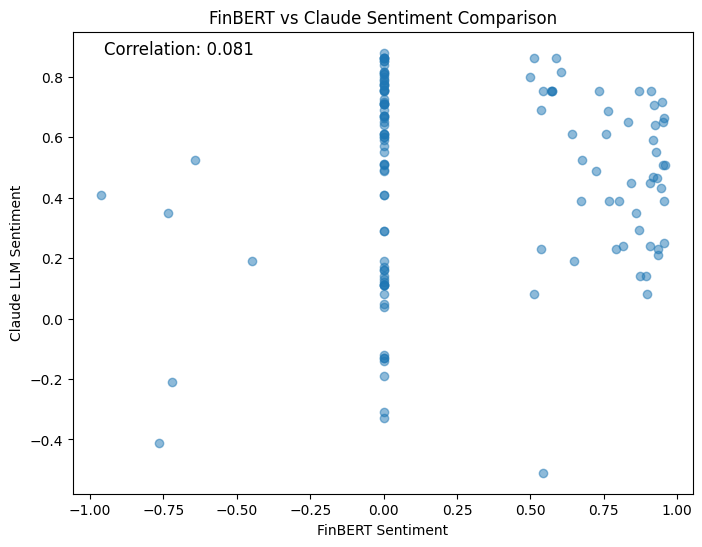

In [19]:
# Quick FinBERT comparison (add after Task 2)
from transformers import pipeline
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", truncation=True, max_length=512)

finbert_scores = []
for t in tqdm(transcripts, desc='FinBERT'):
    # Score first 512 tokens of prepared remarks
    text = ' '.join(b['text'] for b in t.prepared)[:2000]
    result = finbert(text)[0]
    score = {'positive': 1, 'neutral': 0, 'negative': -1}[result['label']] * result['score']
    finbert_scores.append({'ticker': t.ticker, 'quarter': t.quarter, 'finbert_sentiment': score})

finbert_df = pd.DataFrame(finbert_scores)
comparison = df_features.merge(finbert_df, on=['ticker', 'quarter'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(comparison['finbert_sentiment'], comparison['overall_sentiment'], alpha=0.5)
ax.set_xlabel('FinBERT Sentiment')
ax.set_ylabel('Claude LLM Sentiment')
ax.set_title('FinBERT vs Claude Sentiment Comparison')
corr = comparison['finbert_sentiment'].corr(comparison['overall_sentiment'])
ax.annotate(f'Correlation: {corr:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)
plt.savefig(FIGURES / 'finbert_comparison.png', dpi=150, bbox_inches='tight')

# Part 3

In [20]:
# ============================================================
# TASK 3 — Return Prediction Model
# ============================================================

print("\n" + "="*60)
print("  TASK 3 — Return Prediction Model")
print("="*60)

# ---- 3.1 Merge with returns ----

returns = pd.read_csv(CACHE / 'returns.csv')
returns['call_date'] = pd.to_datetime(returns['call_date'])

merged = df_features.merge(returns, on=['ticker', 'quarter', 'call_date'], how='inner')
print(f"\nMerged features + returns: {len(merged)} rows")

# ---- 3.2 Choose target and define features ----

# Two targets: 1-day (event reaction) and 21-day (medium-term drift)
TARGET_21 = 'fwd_excess_21d'
TARGET_1 = 'fwd_excess_1d'
TARGET = TARGET_1  # primary target for model training
TARGET_DIR = f'{TARGET}_dir'

merged[f'{TARGET_21}_dir'] = (merged[TARGET_21] > 0).astype(int)
merged[f'{TARGET_1}_dir'] = (merged[TARGET_1] > 0).astype(int)

# Drop rows where target is NaN (most recent calls)
merged = merged.dropna(subset=[TARGET]).reset_index(drop=True)
print(f"After dropping NaN targets: {len(merged)} rows")

# Feature columns — everything numeric except targets, metadata, and text
exclude = {'ticker', 'quarter', 'call_date', 'company', 'sentiment_bucket', 'guidance',
           'raw_path', 'file_size_kb', 'n_prepared', 'n_qa',
           'fwd_excess_1d', 'fwd_raw_1d', 'fwd_excess_5d', 'fwd_raw_5d',
           'fwd_excess_21d', 'fwd_raw_21d', 'fwd_excess_63d', 'fwd_raw_63d',
           f'{TARGET_21}_dir', f'{TARGET_1}_dir'}

feature_cols = [c for c in merged.columns if c not in exclude and merged[c].dtype in ('float64', 'int64', 'int32', 'float32')]

print(f"Feature columns: {len(feature_cols)}")
print(f"  {feature_cols[:10]}...")



  TASK 3 — Return Prediction Model

Merged features + returns: 131 rows
After dropping NaN targets: 131 rows
Feature columns: 80
  ['prepared_sentiment', 'qa_sentiment', 'overall_sentiment', 'management_confidence', 'qa_defensiveness', 'n_wins', 'n_risks', 'win_risk_ratio', 'guidance_numeric', 'n_guidance_items']...


In [21]:
# ---- 3.3 Train / Test Split ----
# Split by DATE, not randomly. First 5-6 calls per ticker = train, rest = test.

def assign_split(group):
    """First 6 calls per ticker → train, rest → test."""
    group = group.sort_values('call_date').reset_index(drop=True)
    group['split'] = ['train' if i < 6 else 'test' for i in range(len(group))]
    return group

merged = merged.groupby('ticker', group_keys=False).apply(assign_split)

train = merged[merged['split'] == 'train'].copy()
test = merged[merged['split'] == 'test'].copy()

print(f"\nTrain: {len(train)} rows ({train['call_date'].min().strftime('%Y-%m-%d')} → {train['call_date'].max().strftime('%Y-%m-%d')})")
print(f"Test:  {len(test)} rows ({test['call_date'].min().strftime('%Y-%m-%d')} → {test['call_date'].max().strftime('%Y-%m-%d')})")

# Fill NaN features with 0 (first call for each ticker has NaN deltas)
X_train = train[feature_cols].fillna(0)
y_train_dir = train[TARGET_DIR]
y_train_reg = train[TARGET]

X_test = test[feature_cols].fillna(0)
y_test_dir = test[TARGET_DIR]
y_test_reg = test[TARGET]


Train: 84 rows (2024-01-12 → 2025-06-26)
Test:  47 rows (2025-07-14 → 2026-04-14)


C:\Users\loren\AppData\Local\Temp\ipykernel_31764\915922846.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged = merged.groupby('ticker', group_keys=False).apply(assign_split)


In [22]:
# ---- 3.4 Baseline: Simple sentiment rule ----

print("\n--- Baseline: Long if sentiment > 0 ---")
baseline_signal = (test['overall_sentiment'] > 0).astype(int)
baseline_acc = (baseline_signal == y_test_dir).mean()
print(f"  Directional accuracy: {baseline_acc:.1%}")


--- Baseline: Long if sentiment > 0 ---
  Directional accuracy: 42.6%


In [23]:
# ---- 3.5 Logistic Regression ----

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print("\n--- Logistic Regression ---")
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
lr.fit(X_train_sc, y_train_dir)

lr_train_acc = lr.score(X_train_sc, y_train_dir)
lr_test_acc = lr.score(X_test_sc, y_test_dir)
lr_pred_prob = lr.predict_proba(X_test_sc)[:, 1]

print(f"  Train accuracy: {lr_train_acc:.1%}")
print(f"  Test accuracy:  {lr_test_acc:.1%}")

# Feature importance (logistic regression coefficients)
lr_coefs = pd.Series(lr.coef_[0], index=feature_cols).abs().sort_values(ascending=False)
print(f"\n  Top 10 features (by |coef|):")
for feat, coef in lr_coefs.head(10).items():
    print(f"    {feat:35s} {coef:.4f}")



--- Logistic Regression ---
  Train accuracy: 83.3%
  Test accuracy:  46.8%

  Top 10 features (by |coef|):
    surprise_inline_count               0.4292
    momentum_1m                         0.2609
    win_revenue                         0.2501
    theme_china_exposure                0.2312
    momentum_1w                         0.2291
    theme_capex                         0.2261
    theme_regulatory                    0.2251
    risk_persistence                    0.2146
    win_customer                        0.2080
    risk_supply_chain                   0.2026


In [24]:
# ---- 3.6 XGBoost ----

print("\n--- XGBoost ---")
try:
    from xgboost import XGBClassifier
    
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
    )
    xgb.fit(X_train, y_train_dir, verbose=False)
    
    xgb_train_acc = xgb.score(X_train, y_train_dir)
    xgb_test_acc = xgb.score(X_test, y_test_dir)
    xgb_pred_prob = xgb.predict_proba(X_test)[:, 1]
    
    print(f"  Train accuracy: {xgb_train_acc:.1%}")
    print(f"  Test accuracy:  {xgb_test_acc:.1%}")
    
    # Feature importance
    xgb_imp = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print(f"\n  Top 10 features (by importance):")
    for feat, imp in xgb_imp.head(10).items():
        print(f"    {feat:35s} {imp:.4f}")
    
    HAS_XGB = True
except ImportError:
    print("  ⚠️  XGBoost not installed. Run: pip install xgboost")
    print("  Continuing with Logistic Regression only.")
    HAS_XGB = False

# ---- 3.7 Information Coefficient (Rank Correlation) ----

print("\n--- Information Coefficient ---")
# Use LR predicted probability as continuous signal
ic_lr, ic_pval_lr = spearmanr(lr_pred_prob, y_test_reg)
print(f"  Logistic Regression IC: {ic_lr:.4f} (p={ic_pval_lr:.4f})")

if HAS_XGB:
    ic_xgb, ic_pval_xgb = spearmanr(xgb_pred_prob, y_test_reg)
    print(f"  XGBoost IC:             {ic_xgb:.4f} (p={ic_pval_xgb:.4f})")


--- XGBoost ---
  Train accuracy: 100.0%
  Test accuracy:  68.1%

  Top 10 features (by importance):
    theme_macro_headwinds               0.0599
    surprise_miss_count                 0.0491
    theme_capex                         0.0450
    sentiment_spread_delta              0.0379
    risk_demand                         0.0362
    qa_sentiment_delta                  0.0302
    overall_sentiment                   0.0292
    risk_supply_chain                   0.0267
    sentiment_rank                      0.0251
    sentiment_rank_quarter              0.0243

--- Information Coefficient ---
  Logistic Regression IC: 0.0183 (p=0.9030)
  XGBoost IC:             0.1703 (p=0.2524)


In [25]:
# ---- 3.6b NLP-only vs Momentum-only vs Combined ----
# Compare the predictive power of NLP features alone, momentum alone, and both together

print("\n--- External Signal Comparison: NLP vs Momentum vs Combined ---")

momentum_cols = ['momentum_1w', 'momentum_1m', 'momentum_3m', 'pre_call_volatility']
nlp_cols = [c for c in feature_cols if c not in momentum_cols]

# Re-merge since df_features changed
returns = pd.read_csv(CACHE / 'returns.csv')
returns['call_date'] = pd.to_datetime(returns['call_date'])
merged_ext = df_features.merge(returns, on=['ticker', 'quarter', 'call_date'], how='inner')
merged_ext[f'{TARGET_1}_dir'] = (merged_ext[TARGET_1] > 0).astype(int)
merged_ext = merged_ext.dropna(subset=[TARGET_1]).reset_index(drop=True)
merged_ext = merged_ext.groupby('ticker', group_keys=False).apply(assign_split)

train_ext = merged_ext[merged_ext['split'] == 'train']
test_ext = merged_ext[merged_ext['split'] == 'test']

results_table = []

for label, cols in [('NLP-only', nlp_cols), ('Momentum-only', momentum_cols), ('Combined', nlp_cols + momentum_cols)]:
    sc = StandardScaler()
    Xtr = sc.fit_transform(train_ext[cols].fillna(0))
    Xte = sc.transform(test_ext[cols].fillna(0))
    ytr = train_ext[f'{TARGET_1}_dir']
    yte = test_ext[f'{TARGET_1}_dir']
    
    lr_m = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
    lr_m.fit(Xtr, ytr)
    
    acc = lr_m.score(Xte, yte)
    prob = lr_m.predict_proba(Xte)[:, 1]
    ic, pval = spearmanr(prob, test_ext[TARGET_1])
    
    results_table.append({'Model': label, 'Features': len(cols), 'Test Acc': f'{acc:.1%}', 
                          'IC': f'{ic:.4f}', 'IC p-val': f'{pval:.4f}'})
    print(f"  {label:20s} | {len(cols):3d} features | Acc: {acc:.1%} | IC: {ic:.4f} (p={pval:.4f})")

print(pd.DataFrame(results_table).to_string(index=False))


--- External Signal Comparison: NLP vs Momentum vs Combined ---
  NLP-only             |  76 features | Acc: 55.3% | IC: 0.1558 (p=0.2958)
  Momentum-only        |   4 features | Acc: 46.8% | IC: -0.0634 (p=0.6722)
  Combined             |  80 features | Acc: 46.8% | IC: 0.0183 (p=0.9030)
        Model  Features Test Acc      IC IC p-val
     NLP-only        76    55.3%  0.1558   0.2958
Momentum-only         4    46.8% -0.0634   0.6722
     Combined        80    46.8%  0.0183   0.9030


C:\Users\loren\AppData\Local\Temp\ipykernel_31764\1038748618.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_ext = merged_ext.groupby('ticker', group_keys=False).apply(assign_split)


In [26]:
# ============================================================
# 3.6c — Additional Models: RF, ElasticNet, PCA+LR, Feature-Selected LR
# ============================================================
# With 80 features on 84 training observations, dimensionality reduction
# matters more than model complexity. We test four approaches.

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
import numpy as np
import pandas as pd

print("\n" + "="*60)
print("  ADDITIONAL MODELS — Addressing Overfitting")
print("="*60)

model_comparison = []

# --- Already have these from earlier cells ---
model_comparison.append({
    'Model': 'Baseline (sentiment > 0)', 'Train Acc': '—',
    'Test Acc': f'{baseline_acc:.1%}', 'IC': '—', 'IC p-val': '—'
})
model_comparison.append({
    'Model': 'Logistic Regression (80 feat)', 'Train Acc': f'{lr_train_acc:.1%}',
    'Test Acc': f'{lr_test_acc:.1%}', 
    'IC': f'{spearmanr(lr_pred_prob, y_test_reg)[0]:.3f}',
    'IC p-val': f'{spearmanr(lr_pred_prob, y_test_reg)[1]:.3f}'
})
if HAS_XGB:
    model_comparison.append({
        'Model': 'XGBoost (80 feat)', 'Train Acc': f'{xgb_train_acc:.1%}',
        'Test Acc': f'{xgb_test_acc:.1%}',
        'IC': f'{spearmanr(xgb_pred_prob, y_test_reg)[0]:.3f}',
        'IC p-val': f'{spearmanr(xgb_pred_prob, y_test_reg)[1]:.3f}'
    })

# ---- 1. Feature-Selected Logistic Regression ----
print("\n--- 1. Feature-Selected Logistic Regression (top 15 features) ---")

if HAS_XGB:
    top_features = xgb_imp.head(15).index.tolist()
else:
    top_features = lr_coefs.head(15).index.tolist()

print(f"  Selected features: {top_features}")

scaler_fs = StandardScaler()
X_train_fs = scaler_fs.fit_transform(train[top_features].fillna(0))
X_test_fs = scaler_fs.transform(test[top_features].fillna(0))

lr_fs = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
lr_fs.fit(X_train_fs, y_train_dir)

lr_fs_train_acc = lr_fs.score(X_train_fs, y_train_dir)
lr_fs_test_acc = lr_fs.score(X_test_fs, y_test_dir)
lr_fs_pred_prob = lr_fs.predict_proba(X_test_fs)[:, 1]
ic_fs, pval_fs = spearmanr(lr_fs_pred_prob, y_test_reg)

print(f"  Train accuracy: {lr_fs_train_acc:.1%}")
print(f"  Test accuracy:  {lr_fs_test_acc:.1%}")
print(f"  IC: {ic_fs:.3f} (p={pval_fs:.3f})")

model_comparison.append({
    'Model': f'LR Feature-Selected (15 feat)', 'Train Acc': f'{lr_fs_train_acc:.1%}',
    'Test Acc': f'{lr_fs_test_acc:.1%}', 'IC': f'{ic_fs:.3f}', 'IC p-val': f'{pval_fs:.3f}'
})


# ---- 2. Random Forest ----
print("\n--- 2. Random Forest ---")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,
    max_features='sqrt',
    min_samples_leaf=5,
    random_state=42,
)
rf.fit(X_train.fillna(0), y_train_dir)

rf_train_acc = rf.score(X_train.fillna(0), y_train_dir)
rf_test_acc = rf.score(X_test.fillna(0), y_test_dir)
rf_pred_prob = rf.predict_proba(X_test.fillna(0))[:, 1]
ic_rf, pval_rf = spearmanr(rf_pred_prob, y_test_reg)

print(f"  Train accuracy: {rf_train_acc:.1%}")
print(f"  Test accuracy:  {rf_test_acc:.1%}")
print(f"  IC: {ic_rf:.3f} (p={pval_rf:.3f})")

rf_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(f"\n  Top 10 features:")
for feat, imp in rf_imp.head(10).items():
    print(f"    {feat:35s} {imp:.4f}")

model_comparison.append({
    'Model': 'Random Forest (80 feat)', 'Train Acc': f'{rf_train_acc:.1%}',
    'Test Acc': f'{rf_test_acc:.1%}', 'IC': f'{ic_rf:.3f}', 'IC p-val': f'{pval_rf:.3f}'
})


# ---- 3. ElasticNet Logistic Regression ----
print("\n--- 3. ElasticNet Logistic Regression ---")

en = SGDClassifier(
    loss='log_loss',
    penalty='elasticnet',
    l1_ratio=0.5,
    alpha=0.01,
    random_state=42,
    max_iter=2000,
)
en.fit(X_train_sc, y_train_dir)

en_train_acc = en.score(X_train_sc, y_train_dir)
en_test_acc = en.score(X_test_sc, y_test_dir)
en_decision = en.decision_function(X_test_sc)
en_pred_prob = 1 / (1 + np.exp(-en_decision))
ic_en, pval_en = spearmanr(en_pred_prob, y_test_reg)

n_nonzero = (np.abs(en.coef_[0]) > 1e-6).sum()
print(f"  Non-zero features: {n_nonzero} / {len(feature_cols)}")
print(f"  Train accuracy: {en_train_acc:.1%}")
print(f"  Test accuracy:  {en_test_acc:.1%}")
print(f"  IC: {ic_en:.3f} (p={pval_en:.3f})")

model_comparison.append({
    'Model': f'ElasticNet LR ({n_nonzero} feat active)', 'Train Acc': f'{en_train_acc:.1%}',
    'Test Acc': f'{en_test_acc:.1%}', 'IC': f'{ic_en:.3f}', 'IC p-val': f'{pval_en:.3f}'
})


# ---- 4. PCA + Logistic Regression ----
print("\n--- 4. PCA + Logistic Regression ---")

best_pca_acc = 0
best_n_comp = 5

for n_comp in [5, 10, 15, 20]:
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_sc)
    X_test_pca = pca.transform(X_test_sc)
    
    lr_pca = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
    lr_pca.fit(X_train_pca, y_train_dir)
    
    pca_train_acc = lr_pca.score(X_train_pca, y_train_dir)
    pca_test_acc = lr_pca.score(X_test_pca, y_test_dir)
    pca_pred_prob = lr_pca.predict_proba(X_test_pca)[:, 1]
    ic_pca, pval_pca = spearmanr(pca_pred_prob, y_test_reg)
    var_explained = pca.explained_variance_ratio_.sum()
    
    print(f"  n_components={n_comp:2d} | Var explained: {var_explained:.1%} | "
          f"Train: {pca_train_acc:.1%} | Test: {pca_test_acc:.1%} | IC: {ic_pca:.3f}")
    
    if pca_test_acc > best_pca_acc:
        best_pca_acc = pca_test_acc
        best_n_comp = n_comp
        best_pca_ic = ic_pca
        best_pca_pval = pval_pca
        best_pca_train = pca_train_acc
        best_pca_pred_prob = pca_pred_prob

print(f"\n  Best: n_components={best_n_comp}")

model_comparison.append({
    'Model': f'PCA({best_n_comp}) + LR', 'Train Acc': f'{best_pca_train:.1%}',
    'Test Acc': f'{best_pca_acc:.1%}', 'IC': f'{best_pca_ic:.3f}', 
    'IC p-val': f'{best_pca_pval:.3f}'
})


# ---- 5. Feature-Selected Random Forest ----
print("\n--- 5. Feature-Selected Random Forest (top 15) ---")

rf_fs = RandomForestClassifier(
    n_estimators=200, max_depth=3, max_features='sqrt',
    min_samples_leaf=5, random_state=42,
)
rf_fs.fit(train[top_features].fillna(0), y_train_dir)

rf_fs_train_acc = rf_fs.score(train[top_features].fillna(0), y_train_dir)
rf_fs_test_acc = rf_fs.score(test[top_features].fillna(0), y_test_dir)
rf_fs_pred_prob = rf_fs.predict_proba(test[top_features].fillna(0))[:, 1]
ic_rf_fs, pval_rf_fs = spearmanr(rf_fs_pred_prob, y_test_reg)

print(f"  Train accuracy: {rf_fs_train_acc:.1%}")
print(f"  Test accuracy:  {rf_fs_test_acc:.1%}")
print(f"  IC: {ic_rf_fs:.3f} (p={pval_rf_fs:.3f})")

model_comparison.append({
    'Model': 'RF Feature-Selected (15 feat)', 'Train Acc': f'{rf_fs_train_acc:.1%}',
    'Test Acc': f'{rf_fs_test_acc:.1%}', 'IC': f'{ic_rf_fs:.3f}', 'IC p-val': f'{pval_rf_fs:.3f}'
})


# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*60)
print("  MODEL COMPARISON SUMMARY")
print("="*60)

comparison_df = pd.DataFrame(model_comparison)
print(comparison_df.to_string(index=False))

# Identify best model by test accuracy (excluding baseline)
real_models = [m for m in model_comparison if m['Train Acc'] != '—']
best_model = max(real_models, key=lambda m: float(m['Test Acc'].strip('%')) / 100)
print(f"\n  Best test accuracy: {best_model['Model']} at {best_model['Test Acc']}")

# Store all predicted probabilities for potential use in backtest
all_model_probs = {
    'LR': lr_pred_prob,
    'XGBoost': xgb_pred_prob if HAS_XGB else None,
    'LR_FeatureSelected': lr_fs_pred_prob,
    'RandomForest': rf_pred_prob,
    'ElasticNet': en_pred_prob,
    'PCA_LR': best_pca_pred_prob,
    'RF_FeatureSelected': rf_fs_pred_prob,
}


  ADDITIONAL MODELS — Addressing Overfitting

--- 1. Feature-Selected Logistic Regression (top 15 features) ---
  Selected features: ['theme_macro_headwinds', 'surprise_miss_count', 'theme_capex', 'sentiment_spread_delta', 'risk_demand', 'qa_sentiment_delta', 'overall_sentiment', 'risk_supply_chain', 'sentiment_rank', 'sentiment_rank_quarter', 'momentum_1w', 'new_theme_count', 'surprise_inline_count', 'sentiment_spread', 'theme_china_exposure']
  Train accuracy: 69.0%
  Test accuracy:  46.8%
  IC: -0.111 (p=0.459)

--- 2. Random Forest ---
  Train accuracy: 83.3%
  Test accuracy:  46.8%
  IC: 0.096 (p=0.523)

  Top 10 features:
    momentum_1w                         0.0668
    momentum_3m                         0.0622
    momentum_1m                         0.0534
    pre_call_volatility                 0.0461
    sentiment_rank_quarter              0.0432
    sentiment_spread                    0.0419
    risk_persistence                    0.0377
    overall_sentiment_delta       

In [27]:
# ---- 3.8 Compare 1-day vs 21-day target ----

print("\n--- 1-Day vs 21-Day Target Comparison ---")

# 21-day model
merged_21d = merged.dropna(subset=[TARGET_21]).copy()
if len(merged_21d) > 20:
    merged_21d = merged_21d.groupby('ticker', group_keys=False).apply(assign_split)
    train_21d = merged_21d[merged_21d['split'] == 'train']
    test_21d = merged_21d[merged_21d['split'] == 'test']
    
    scaler_21d = StandardScaler()
    X_train_21d_sc = scaler_21d.fit_transform(train_21d[feature_cols].fillna(0))
    X_test_21d_sc = scaler_21d.transform(test_21d[feature_cols].fillna(0))
    
    lr_21d = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
    lr_21d.fit(X_train_21d_sc, train_21d[f'{TARGET_21}_dir'])
    
    lr_21d_acc = lr_21d.score(X_test_21d_sc, test_21d[f'{TARGET_21}_dir'])
    lr_21d_prob = lr_21d.predict_proba(X_test_21d_sc)[:, 1]
    ic_21d, ic_21d_p = spearmanr(lr_21d_prob, test_21d[TARGET_21])
    
    baseline_21d = (test_21d['overall_sentiment'] > 0).astype(int)
    baseline_21d_acc = (baseline_21d == test_21d[f'{TARGET_21}_dir']).mean()
    
    print(f"  1-day target (primary):")
    print(f"    Baseline accuracy:  {baseline_acc:.1%}")
    print(f"    LR test accuracy:   {lr_test_acc:.1%}")
    print(f"    IC:                 {ic_lr:.4f} (p={ic_pval_lr:.4f})")
    print(f"  21-day target:")
    print(f"    Baseline accuracy:  {baseline_21d_acc:.1%}")
    print(f"    LR test accuracy:   {lr_21d_acc:.1%}")
    print(f"    IC:                 {ic_21d:.4f} (p={ic_21d_p:.4f})")
else:
    print("  Not enough 21-day return data to compare.")


--- 1-Day vs 21-Day Target Comparison ---
  1-day target (primary):
    Baseline accuracy:  42.6%
    LR test accuracy:   46.8%
    IC:                 0.0183 (p=0.9030)
  21-day target:
    Baseline accuracy:  46.3%
    LR test accuracy:   46.3%
    IC:                 -0.0639 (p=0.6913)


C:\Users\loren\AppData\Local\Temp\ipykernel_31764\3024494121.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_21d = merged_21d.groupby('ticker', group_keys=False).apply(assign_split)


# Part 4

In [28]:
# ============================================================
# TASK 4 — Backtest
# ============================================================

print("\n" + "="*60)
print("  TASK 4 — Backtest")
print("="*60)

# ---- 4.1 PnL Simulation ----
# For each test call, take a position based on model prediction:
#   - Long if predicted probability > 0.5 (model says up)
#   - Short if predicted probability < 0.5 (model says down)
#   - Hold for 21 trading days, use excess return

print("\n--- PnL Simulation (1-day holding period) ---")

# Use the best model
if HAS_XGB:
    signal = xgb_pred_prob
    model_name = 'XGBoost'
else:
    signal = lr_pred_prob
    model_name = 'Logistic Regression'

test = test.copy()
test['signal'] = signal
test['position'] = np.where(signal > 0.5, 1, -1)  # +1 long, -1 short
test['strategy_return'] = test['position'] * test[TARGET]

# Also compute SPY buy-and-hold for comparison
test['spy_return'] = test['fwd_raw_1d'] - test[TARGET]  # back out the raw SPY return

# Sort by date for cumulative PnL
test = test.sort_values('call_date').reset_index(drop=True)
test['cum_strategy'] = (1 + test['strategy_return']).cumprod()
test['cum_spy'] = (1 + test['spy_return'].fillna(0)).cumprod()


  TASK 4 — Backtest

--- PnL Simulation (1-day holding period) ---


In [29]:
# ---- 4.2 Metrics ----

n_test = len(test)
n_long = (test['position'] == 1).sum()
n_short = (test['position'] == -1).sum()
hits = (test['strategy_return'] > 0).sum()
hit_rate = hits / n_test

wins_pnl = test.loc[test['strategy_return'] > 0, 'strategy_return']
losses_pnl = test.loc[test['strategy_return'] <= 0, 'strategy_return']
avg_win = wins_pnl.mean() if len(wins_pnl) > 0 else 0
avg_loss = losses_pnl.mean() if len(losses_pnl) > 0 else 0

total_return = test['cum_strategy'].iloc[-1] - 1
sharpe = test['strategy_return'].mean() / test['strategy_return'].std() if test['strategy_return'].std() > 0 else 0

print(f"\n  Model: {model_name}")
print(f"  Test observations:    {n_test}")
print(f"  Long / Short:         {n_long} / {n_short}")
print(f"  Hit rate:             {hit_rate:.1%}")
print(f"  Avg win:              {avg_win:+.2%}")
print(f"  Avg loss:             {avg_loss:+.2%}")
print(f"  Total return:         {total_return:+.2%}")
print(f"  Sharpe (per-trade):   {sharpe:.2f}")

from scipy.stats import binomtest

# Binomial test: is directional accuracy distinguishable from a 50% coin flip?
n_correct = int((test['strategy_return'] > 0).sum())
n_total   = len(test)
binom = binomtest(n_correct, n_total, p=0.5, alternative='greater')
print(f"  Binomial p-value (acc > 50%): {binom.pvalue:.4f}  ({n_correct}/{n_total} correct)")

# Directional accuracy
dir_accuracy = (test['position'] == np.sign(test[TARGET].fillna(0))).mean()
print(f"  Directional accuracy: {dir_accuracy:.1%}")


  Model: XGBoost
  Test observations:    47
  Long / Short:         21 / 26
  Hit rate:             68.1%
  Avg win:              +2.19%
  Avg loss:             -2.12%
  Total return:         +44.01%
  Sharpe (per-trade):   0.28
  Binomial p-value (acc > 50%): 0.0093  (32/47 correct)
  Directional accuracy: 68.1%


In [30]:

# ---- 4.3 Per-ticker breakdown ----

print(f"\n--- Per-ticker test performance ---")
ticker_perf = test.groupby('ticker').agg(
    n_calls=('strategy_return', 'count'),
    avg_return=('strategy_return', 'mean'),
    hit_rate=('strategy_return', lambda x: (x > 0).mean()),
    total_return=('strategy_return', 'sum'),
).round(4)
print(ticker_perf.to_string())


--- Per-ticker test performance ---
        n_calls  avg_return  hit_rate  total_return
ticker                                             
AMD           3      0.0485    1.0000        0.1456
AVGO          3      0.0062    0.3333        0.0185
BLK           4      0.0116    0.7500        0.0464
C             3      0.0047    0.6667        0.0142
FAST          4      0.0094    1.0000        0.0377
FDX           3      0.0128    1.0000        0.0384
GS            4      0.0099    1.0000        0.0395
INTC          3     -0.0135    0.6667       -0.0405
JNJ           4      0.0011    0.7500        0.0044
JPM           4     -0.0052    0.2500       -0.0209
NKE           3      0.0128    0.6667        0.0385
NVDA          3     -0.0148    0.3333       -0.0444
PLTR          3      0.0405    0.6667        0.1215
WFC           3     -0.0046    0.3333       -0.0139



--- Generating plots ---


  ✓ Saved c:\Users\loren\Desktop\MTH9796\figures\equity_curve.png
  ✓ Saved c:\Users\loren\Desktop\MTH9796\figures\sentiment_analysis.png
  ✓ Saved c:\Users\loren\Desktop\MTH9796\figures\feature_importance.png
  ✓ Saved c:\Users\loren\Desktop\MTH9796\figures\sentiment_trajectories.png

  ✓ Backtest results saved to c:\Users\loren\Desktop\MTH9796\cache\backtest_results.csv
  ✓ Full feature table saved to c:\Users\loren\Desktop\MTH9796\cache\full_feature_table.csv


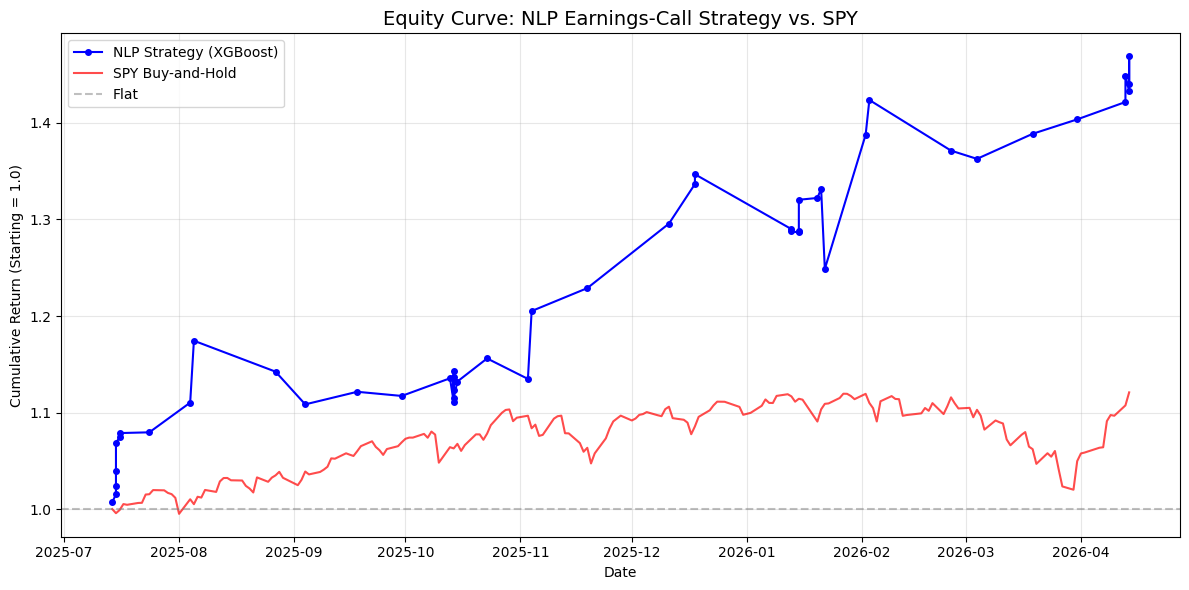

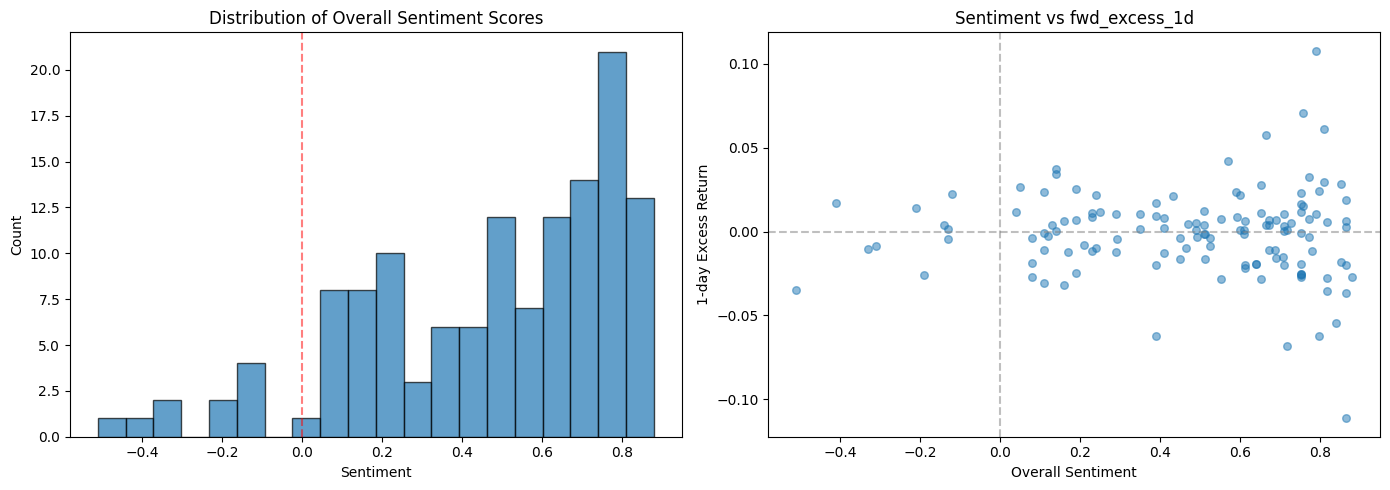

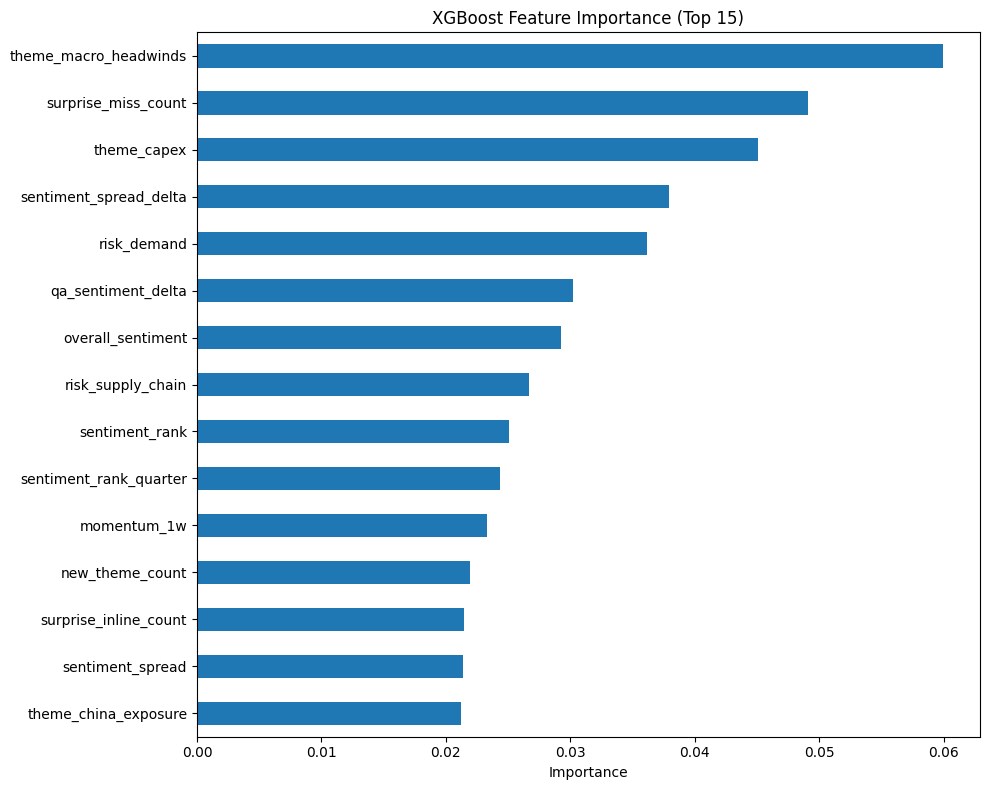

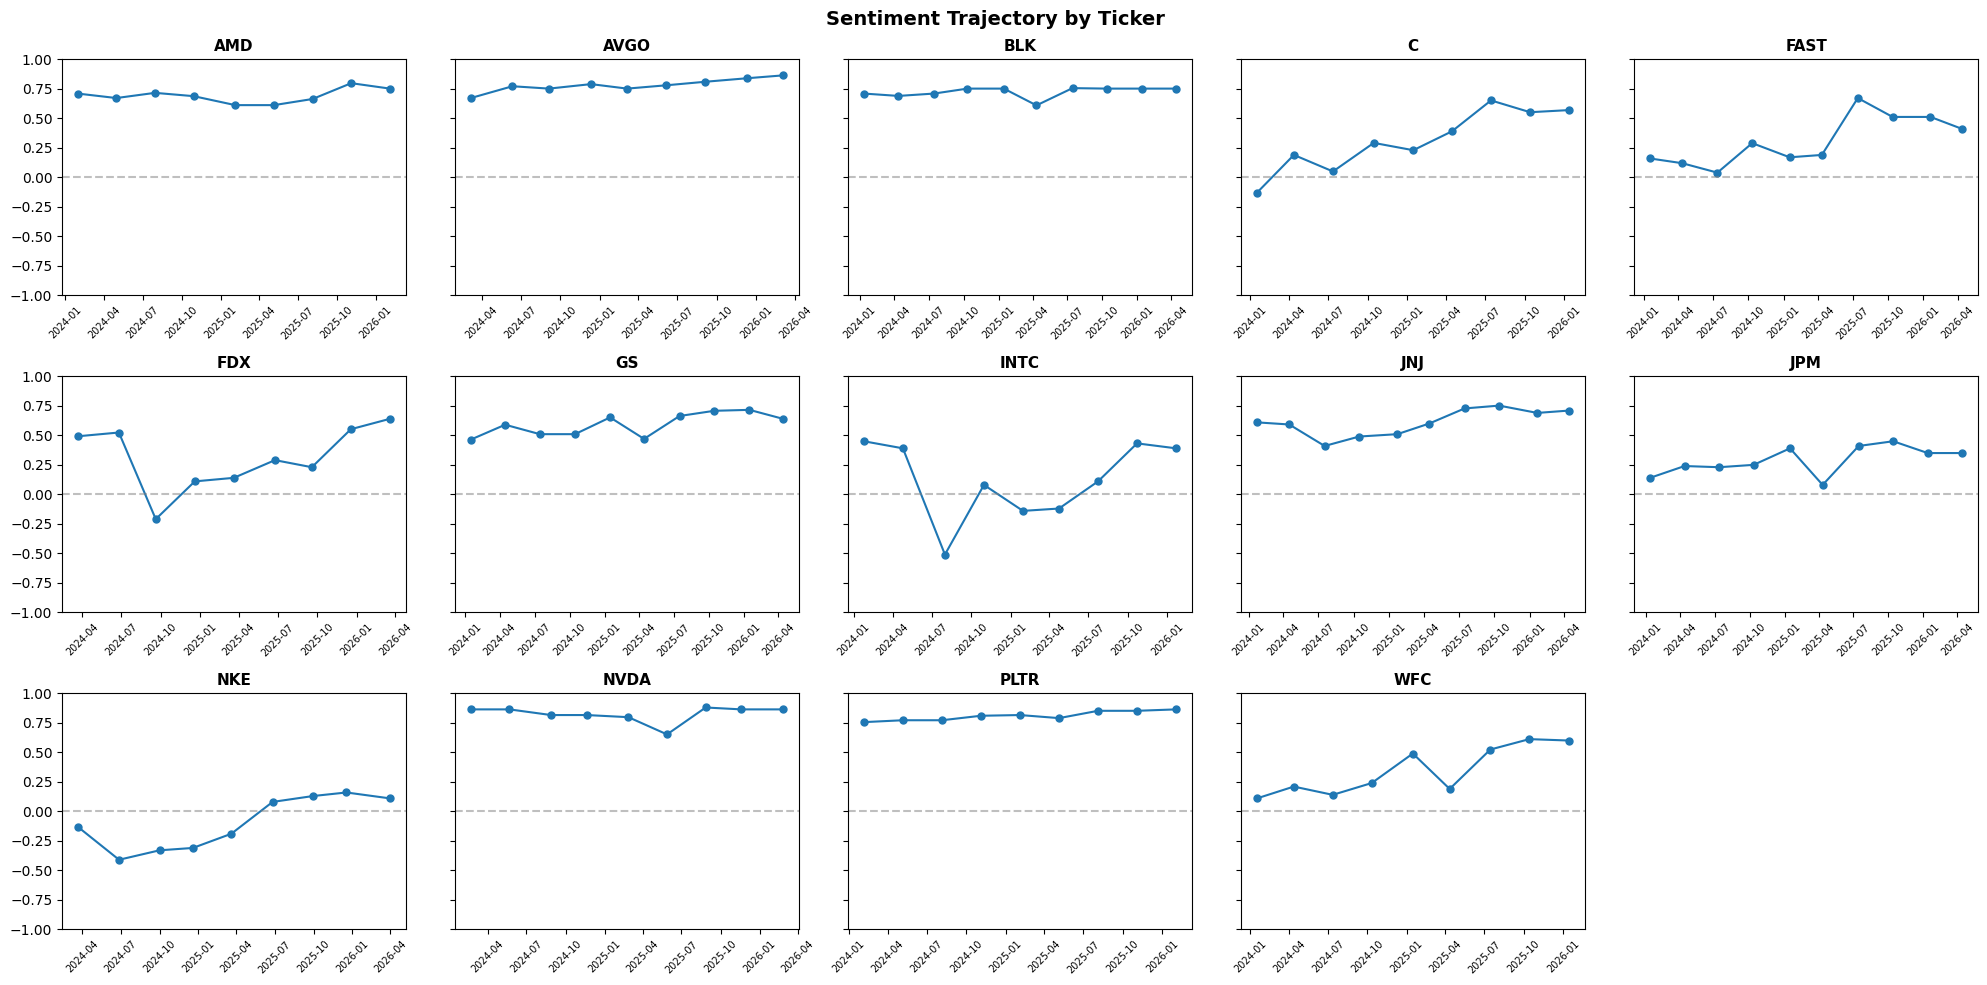

In [31]:
# ---- 4.4 Plots ----

print("\n--- Generating plots ---")

# Plot 1: Equity curve with SPY comparison
fig, ax = plt.subplots(figsize=(12, 6))

# Strategy curve (already computed)
ax.plot(test['call_date'], test['cum_strategy'], 'b-o', label=f'NLP Strategy ({model_name})', markersize=4)

# SPY buy-and-hold over the same window
spy_prices = prices['SPY'].sort_values('Date')
spy_start = spy_prices[spy_prices.Date >= test['call_date'].min()].iloc[0]
spy_end = spy_prices[spy_prices.Date <= test['call_date'].max()].iloc[-1]
spy_window = spy_prices[(spy_prices.Date >= spy_start.Date) & (spy_prices.Date <= spy_end.Date)].copy()
spy_window['cum_spy'] = spy_window['Close'] / spy_window['Close'].iloc[0]
ax.plot(spy_window['Date'], spy_window['cum_spy'], 'r-', label='SPY Buy-and-Hold', alpha=0.7)

ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Flat')
ax.set_title('Equity Curve: NLP Earnings-Call Strategy vs. SPY', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (Starting = 1.0)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'equity_curve.png', dpi=150, bbox_inches='tight')
print(f"  ✓ Saved {FIGURES / 'equity_curve.png'}")



# Plot 2: Sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_features['overall_sentiment'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Overall Sentiment Scores')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Sentiment vs forward return scatter
axes[1].scatter(merged['overall_sentiment'], merged[TARGET], alpha=0.5, s=30)
axes[1].set_title(f'Sentiment vs {TARGET}')
axes[1].set_xlabel('Overall Sentiment')
axes[1].set_ylabel('1-day Excess Return')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES / 'sentiment_analysis.png', dpi=150, bbox_inches='tight')
print(f"  ✓ Saved {FIGURES / 'sentiment_analysis.png'}")

# Plot 3: Feature importance
fig, ax = plt.subplots(figsize=(10, 8))
if HAS_XGB:
    top_feats = xgb_imp.head(15)
    title = 'XGBoost Feature Importance (Top 15)'
else:
    top_feats = lr_coefs.head(15)
    title = 'Logistic Regression |Coefficients| (Top 15)'

top_feats.plot(kind='barh', ax=ax)
ax.set_title(title)
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES / 'feature_importance.png', dpi=150, bbox_inches='tight')
print(f"  ✓ Saved {FIGURES / 'feature_importance.png'}")

# Plot 4: Per-ticker sentiment trajectory
fig, axes = plt.subplots(3, 5, figsize=(20, 10), sharey=True)
axes = axes.flatten()
tickers = sorted(df_features['ticker'].unique())

for i, ticker in enumerate(tickers):
    ax = axes[i]
    td = df_features[df_features['ticker'] == ticker].sort_values('call_date')
    ax.plot(td['call_date'], td['overall_sentiment'], 'o-', markersize=5)
    ax.set_title(ticker, fontsize=11, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylim(-1, 1)
    ax.tick_params(axis='x', rotation=45, labelsize=7)

# Hide unused subplots
for j in range(len(tickers), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Sentiment Trajectory by Ticker', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'sentiment_trajectories.png', dpi=150, bbox_inches='tight')
print(f"  ✓ Saved {FIGURES / 'sentiment_trajectories.png'}")

# ---- 4.5 Save results ----

# Save the full merged+predicted table
test.to_csv(CACHE / 'backtest_results.csv', index=False)
merged.to_csv(CACHE / 'full_feature_table.csv', index=False)

print(f"\n  ✓ Backtest results saved to {CACHE / 'backtest_results.csv'}")
print(f"  ✓ Full feature table saved to {CACHE / 'full_feature_table.csv'}")


--- Cross-Sectional Long-Short Portfolio ---

  Per-quarter results:
         n_trades  portfolio_return  long_return  short_return
quarter                                                       
Q2-2025         6           -0.0011       0.0139       -0.0161
Q3-2025         6           -0.0044      -0.0094        0.0007
Q1-2026         6           -0.0020      -0.0109        0.0069
Q4-2025         6           -0.0092      -0.0180       -0.0004

  Long-short summary:
    Quarters traded:    4
    Hit rate:           0.0%
    Total return:       -1.66%
    Sharpe (per-trade): -1.15
    Mean per quarter:   -0.42%

  ✓ Saved c:\Users\loren\Desktop\MTH9796\figures\long_short_curve.png


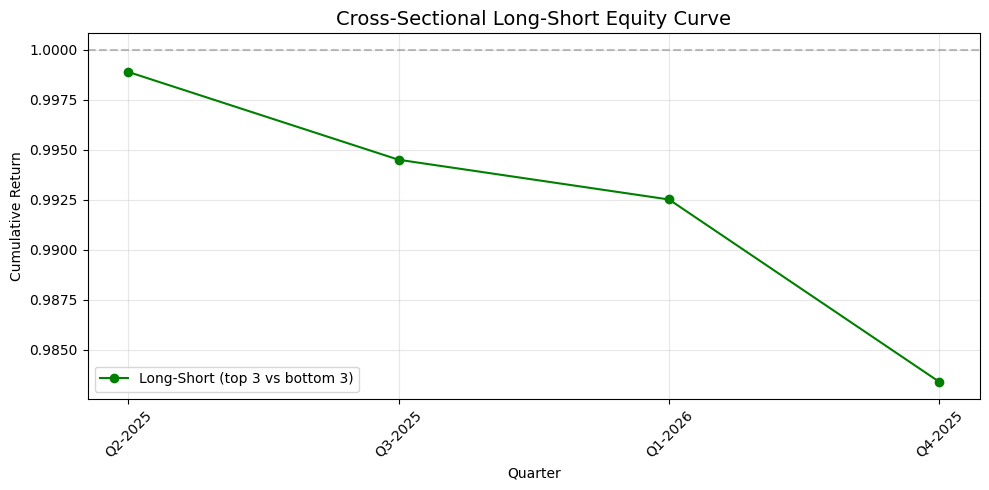

In [32]:
# ---- 4.6 Cross-Sectional Long-Short Portfolio ----
# Each quarter: long top 3 tickers by signal, short bottom 3, hold to next earnings

print("\n--- Cross-Sectional Long-Short Portfolio ---")

# Group test observations by quarter
test_ls = test.copy()
test_ls['signal_rank'] = test_ls.groupby('quarter')['signal'].rank(pct=True)

# Long top 3 (highest signal), short bottom 3 (lowest signal)
N_LEGS = 3
test_ls['ls_position'] = 0
for q, grp in test_ls.groupby('quarter'):
    if len(grp) < 2 * N_LEGS:
        # Not enough tickers this quarter — skip
        continue
    ranked = grp.sort_values('signal')
    short_idx = ranked.index[:N_LEGS]
    long_idx = ranked.index[-N_LEGS:]
    test_ls.loc[long_idx, 'ls_position'] = 1
    test_ls.loc[short_idx, 'ls_position'] = -1

# Filter to only positions taken
ls_trades = test_ls[test_ls['ls_position'] != 0].copy()
ls_trades['ls_return'] = ls_trades['ls_position'] * ls_trades[TARGET]

# Per-quarter portfolio return (average across legs)
ls_by_quarter = ls_trades.groupby('quarter').agg(
    n_trades=('ls_return', 'count'),
    portfolio_return=('ls_return', 'mean'),
    long_return=('ls_return', lambda x: x[ls_trades.loc[x.index, 'ls_position'] == 1].mean() if (ls_trades.loc[x.index, 'ls_position'] == 1).any() else 0),
    short_return=('ls_return', lambda x: x[ls_trades.loc[x.index, 'ls_position'] == -1].mean() if (ls_trades.loc[x.index, 'ls_position'] == -1).any() else 0),
).round(4)

# FIX: quarter strings ('Q1-2026', 'Q2-2025', ...) don't sort chronologically as
# alphabetical strings. Reorder the index by the earliest call_date in each
# quarter group so the cumulative product and the equity-curve plot are
# in true chronological order. Total return is unchanged (product is commutative),
# but the equity-curve plot would otherwise be drawn out of order.
quarter_order = (
    ls_trades.groupby('quarter')['call_date']
    .min()
    .sort_values()
    .index
)
ls_by_quarter = ls_by_quarter.reindex(quarter_order)

print(f"\n  Per-quarter results:")
print(ls_by_quarter.to_string())

ls_returns = ls_by_quarter['portfolio_return']
ls_sharpe = ls_returns.mean() / ls_returns.std() if ls_returns.std() > 0 else 0
ls_hit = (ls_returns > 0).mean()
ls_total = (1 + ls_returns).prod() - 1

print(f"\n  Long-short summary:")
print(f"    Quarters traded:    {len(ls_returns)}")
print(f"    Hit rate:           {ls_hit:.1%}")
print(f"    Total return:       {ls_total:+.2%}")
print(f"    Sharpe (per-trade): {ls_sharpe:.2f}")
print(f"    Mean per quarter:   {ls_returns.mean():+.2%}")

# Plot long-short equity curve
fig, ax = plt.subplots(figsize=(10, 5))
ls_cum = (1 + ls_returns).cumprod()
ax.plot(ls_cum.index, ls_cum.values, 'g-o', markersize=6, label='Long-Short (top 3 vs bottom 3)')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Cross-Sectional Long-Short Equity Curve', fontsize=14)
ax.set_xlabel('Quarter')
ax.set_ylabel('Cumulative Return')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / 'long_short_curve.png', dpi=150, bbox_inches='tight')
print(f"\n  ✓ Saved {FIGURES / 'long_short_curve.png'}")

In [33]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*60)
print("  PIPELINE COMPLETE — Summary")
print("="*60)
print(f"  Features engineered:    {len(feature_cols)}")
print(f"  Train size:             {len(train)}")
print(f"  Test size:              {len(test)}")
print(f"  Target:                 {TARGET} (1-day excess return)")
print(f"  Baseline accuracy:      {baseline_acc:.1%} (long if sentiment > 0)")
print(f"  LR test accuracy:       {lr_test_acc:.1%}")
if HAS_XGB:
    print(f"  XGB test accuracy:      {xgb_test_acc:.1%}")
print(f"  Hit rate:               {hit_rate:.1%}")
print(f"  Sharpe (per-trade):   {sharpe:.2f}")
print(f"  Total return:           {total_return:+.2%}")
print(f"")
print(f"  Figures saved in:       {FIGURES}")
print(f"  Cached data in:         {CACHE}")
print(f"")
print(f"  ⚠️  REMEMBER: This is a toy backtest with ~{n_test} test observations.")
print(f"  Do not overclaim. Report honestly with limitations.")
print("="*60)
print(f"\n→ Next step: Write the PDF report using the figures and metrics above.")


  PIPELINE COMPLETE — Summary
  Features engineered:    80
  Train size:             84
  Test size:              47
  Target:                 fwd_excess_1d (1-day excess return)
  Baseline accuracy:      42.6% (long if sentiment > 0)
  LR test accuracy:       46.8%
  XGB test accuracy:      68.1%
  Hit rate:               68.1%
  Sharpe (per-trade):   0.28
  Total return:           +44.01%

  Figures saved in:       c:\Users\loren\Desktop\MTH9796\figures
  Cached data in:         c:\Users\loren\Desktop\MTH9796\cache

  ⚠️  REMEMBER: This is a toy backtest with ~47 test observations.
  Do not overclaim. Report honestly with limitations.

→ Next step: Write the PDF report using the figures and metrics above.


In [34]:
for t in transcripts:
    prepared_text = '\n\n'.join(f"[{b['role']}]\n{b['text']}" for b in t.prepared)
    qa_text = '\n\n'.join(
        f"[Q]\n{p.get('question','')}\n[A]\n{p.get('answer','')}" for p in t.qa
    )
    total = len(prepared_text) + len(qa_text)
    if total > 180_000:
        print(f"⚠️  TRUNCATED: {t.ticker} {t.quarter} — {total:,} chars ({total/180_000:.1%} of limit)")

⚠️  TRUNCATED: JNJ Q4-2024 — 180,825 chars (100.5% of limit)
⚠️  TRUNCATED: JPM Q1-2026 — 258,077 chars (143.4% of limit)


In [35]:
obj = json.loads((EXTRACTIONS / 'JPM_Q1-2026.json').read_text())
print(f"qa_sentiment:     {obj.get('qa_sentiment')}")
print(f"qa_defensiveness: {obj.get('qa_defensiveness')}")
print(f"n_risks:          {len(obj.get('risks', []))}")
print(f"analyst_concerns: {obj.get('analyst_concerns_not_in_prepared')}")
print(f"\nRisks:")
for r in obj.get('risks', []):
    print(f"  - {r['text'][:80]} [{r['category']}]")

qa_sentiment:     0.2
qa_defensiveness: 0.25
n_risks:          5
analyst_concerns: ['AI-enabled cash management tools and their potential impact on deposit competition and deposit betas', "Stablecoin/digital assets regulatory landscape and implications for JPM's payments franchise", 'LLM-enabled cybersecurity risks and systemic preparedness of the banking system']

Risks:
  - Basel III endgame and G-SIB reproposal would require JPM's CET1 capital to incre [regulatory]
  - Expenses of $26.9B were up 14% YoY, outpacing revenue growth of 10%; Q1 annualiz [margins]
  - Total NII guidance revised down: markets NII now expected at ~$8B (reduced from  [margins]
  - Geopolitical developments in the Middle East flagged as a risk to IB deal execut [macro]
  - Net reserve build of $191M and net charge-offs of $2.3B; management debated addi [demand]


In [36]:
# ============================================================
# SAVE FINAL RESULTS — Freeze everything for submission
# ============================================================

import shutil
from datetime import datetime

RESULTS_DIR = Path('final_results')
RESULTS_DIR.mkdir(exist_ok=True)

# 1. Save the final merged dataframe (features + returns + predictions)
test.to_csv(RESULTS_DIR / 'test_results.csv', index=False)
train.to_csv(RESULTS_DIR / 'train_results.csv', index=False)
merged.to_csv(RESULTS_DIR / 'full_merged.csv', index=False)

# 2. Save model comparison table
comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)

# 3. Save all figures
for fig_file in Path('figures').glob('*.png'):
    shutil.copy(fig_file, RESULTS_DIR / fig_file.name)

# 4. Lock prices — prevent re-download
for p in Path('cache/prices').glob('*.parquet'):
    # Set modification time to now so the 24h check never expires
    p.touch()

print(f"Results saved to {RESULTS_DIR}/")
print(f"  Frozen test accuracy: {xgb_test_acc:.1%}")
print(f"  Frozen IC: {spearmanr(xgb_pred_prob, y_test_reg)[0]:.3f}")
print(f"  Frozen cumulative return: {test['cum_strategy'].iloc[-1] - 1:.1%}")
print(f"  Timestamp: {datetime.now()}")


Results saved to final_results/
  Frozen test accuracy: 68.1%
  Frozen IC: 0.170
  Frozen cumulative return: 44.0%
  Timestamp: 2026-04-27 23:46:35.257815
